Stocks vol R² from shared factors (all 6 PCs): 0.122
Stocks coupling betas: [-0.09242833  0.25326548  0.00607701  0.02041494 -0.28593727 -0.0563281 ]
Stocks coupling boost: 5x, idio scale: 0.107
Boosted shared var fraction: 3.060
  Vol PC1: phi=0.9942, c=-0.0010, resid_std=0.1909, target_std=1.8188
  Vol PC2: phi=0.9929, c=0.0006, resid_std=0.1173, target_std=1.0364
  Vol PC3: phi=0.9866, c=-0.0002, resid_std=0.1406, target_std=0.8534
  Vol PC4: phi=0.9836, c=0.0001, resid_std=0.1138, target_std=0.6315
  Vol PC5: phi=0.9536, c=0.0003, resid_std=0.1668, target_std=0.5468
  Vol PC6: phi=0.9617, c=-0.0001, resid_std=0.1202, target_std=0.4376
  Stocks idio vol: phi=0.9716, resid_std=0.0619

True model log(h_sim) correlations:
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor          1.00     0.59        0.58   -0.28   0.54   0.60          0.15
guitars         0.59     1.00        0.69   -0.68   0.67   0.55         -0.09
slingshots      0.58     0.69     

VALIDATION

Correlation matrix comparison:
Original:
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor         1.000   -0.326      -0.291  -0.045 -0.081  0.623        -0.148
guitars       -0.326    1.000       0.553   0.028  0.216 -0.369         0.269
slingshots    -0.291    0.553       1.000   0.018  0.127 -0.259         0.210
stocks        -0.045    0.028       0.018   1.000 -0.021 -0.050         0.002
sugar         -0.081    0.216       0.127  -0.021  1.000 -0.091         0.142
water          0.623   -0.369      -0.259  -0.050 -0.091  1.000        -0.180
tranquillity  -0.148    0.269       0.210   0.002  0.142 -0.180         1.000

Simulated:
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor         1.000   -0.296      -0.311  -0.050 -0.092  0.596        -0.168
guitars       -0.296    1.000       0.518   0.033  0.212 -0.343         0.240
slingshots    -0.311    0.518       1.000   0.016  0.145 -0.263         0.229

  sugar: 0.9925
  water: 0.9869
  tranquillity: 0.9922

CONDITIONAL VOLATILITY CORRELATIONS



Original conditional vol correlations:
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor          1.00     0.59        0.58   -0.10   0.54   0.60          0.15
guitars         0.59     1.00        0.69   -0.24   0.67   0.55         -0.09
slingshots      0.58     0.69        1.00   -0.06   0.65   0.47          0.29
stocks         -0.10    -0.24       -0.06    1.00  -0.22  -0.13          0.20
sugar           0.54     0.67        0.65   -0.22   1.00   0.32          0.10
water           0.60     0.55        0.47   -0.13   0.32   1.00          0.16
tranquillity    0.15    -0.09        0.29    0.20   0.10   0.16          1.00

Simulated conditional vol correlations:
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor          1.00     0.54        0.54   -0.11   0.50   0.57          0.12
guitars         0.54     1.00        0.66   -0.30   0.62   0.49         -0.07
slingshots      0.54     0.66        1.00   -0.09   0.58   0.

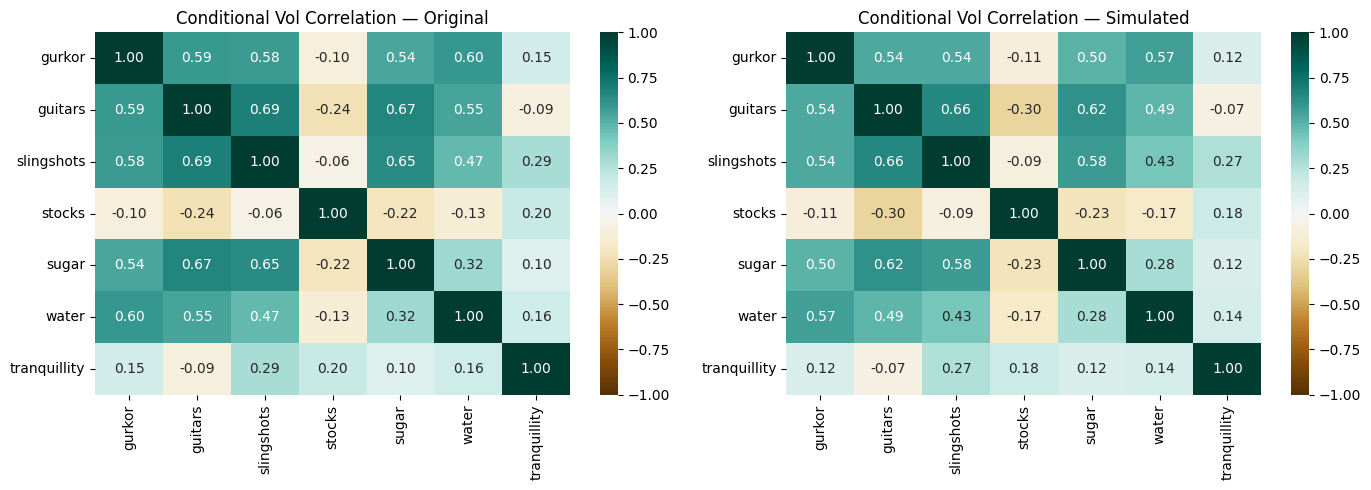

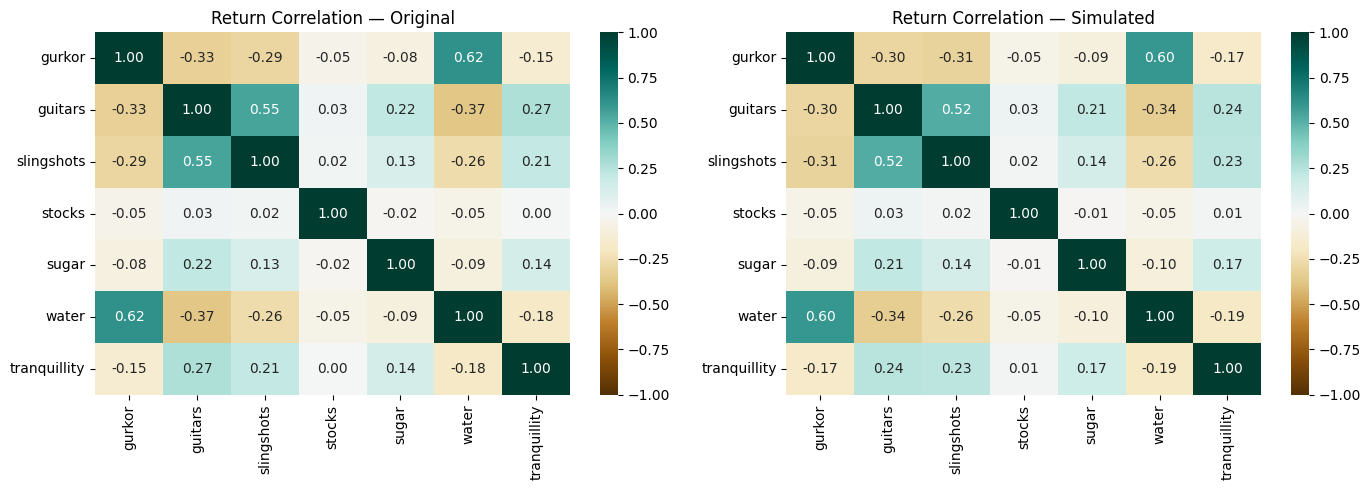

In [1]:
import numpy as np
import pandas as pd
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA
from arch import arch_model
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, t as student_t
from numpy.linalg import eigh

THEME = 'BrBG'

# =============================================================================
# Load data
# =============================================================================
df_og = pd.read_csv('../data/spiff_data-2.csv')
df_og = df_og.replace(1000, np.nan).iloc[1450:]
df_original = df_og.drop(columns=['Unnamed: 0']).set_index('day')

df_og_returns = (df_original / df_original.shift(1) - 1).dropna()
original_mean = df_og_returns.mean()
df_og_returns = df_og_returns - original_mean
original_stds = df_og_returns.std()

var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']
stocks_idx = var_names.index('stocks')
non_stock_names = [v for v in var_names if v != 'stocks']
non_stock_idx = [i for i, v in enumerate(var_names) if v != 'stocks']

# =============================================================================
# VAR(2) parameters
# =============================================================================
Phi1 = np.array([
    [ 0.066837, -0.047029, -0.032074, -0.129388, -0.120289, -0.162173,  0.029557],
    [ 0.123793, -0.006606,  0.033206, -0.265276, -0.075745,  0.035917, -0.058590],
    [ 0.026951,  0.015659,  0.000864, -0.045200, -0.024831,  0.035934, -0.043809],
    [ 0.199106,  0.007784,  0.014711, -0.220926, -0.061257, -0.002547,  0.039002],
    [-0.032751, -0.034423,  0.000487,  0.013779, -0.016192, -0.075896, -0.035988],
    [ 0.016032, -0.018288, -0.006550, -0.033598, -0.052375, -0.296606, -0.023336],
    [-0.014400, -0.001650,  0.021113, -0.040414,  0.006551,  0.035195, -0.182736]
])

Phi2 = np.array([
    [ 0.018276, -0.036829,  0.023368, -0.076605,  0.003404, -0.084637, -0.044700],
    [ 0.040158, -0.042788,  0.016656, -0.044778,  0.012176,  0.000934, -0.006445],
    [ 0.010401, -0.001657, -0.015511, -0.017275, -0.028722, -0.011827,  0.032037],
    [ 0.019280, -0.000785, -0.004241, -0.047150,  0.031045,  0.018171, -0.054329],
    [ 0.005180,  0.028481,  0.002092,  0.008334, -0.009077,  0.014023, -0.009718],
    [ 0.011509, -0.018017, -0.012928,  0.000614,  0.004906, -0.070937,  0.004123],
    [-0.004617,  0.034619,  0.008011, -0.010612, -0.000637,  0.029500, -0.061284]
])

# =============================================================================
# Kurtosis / t-distribution parameters
# =============================================================================
nu_obs = {
    'gurkor': 21.72, 'guitars': 18.53, 'slingshots': 32.79,
    'stocks': 401.88, 'sugar': 17.69, 'water': 22.65, 'tranquillity': 16.41
}
nu_target = {
    'gurkor': 5.66, 'guitars': 5.04, 'slingshots': 5.28,
    'stocks': 132.55, 'sugar': 4.45, 'water': 7.65, 'tranquillity': 6.31
}
alpha_blend = {
    'gurkor': 0.87, 'guitars': 0.3, 'slingshots': 0.96,
    'stocks': 0.8, 'sugar': 1.06, 'water': 0.8, 'tranquillity': 0.7,
}
nu_blended = {col: nu_obs[col] + alpha_blend[col] * (nu_target[col] - nu_obs[col]) for col in var_names}
t_scales = {col: 1.0 / np.sqrt(nu_blended[col] / (nu_blended[col] - 2)) for col in var_names}

# =============================================================================
# GARCH on original data — save params
# =============================================================================
cond_var_og = pd.DataFrame(index=df_og_returns.index, columns=var_names, dtype=float)
original_garch_params = {}

for col in var_names:
    model = arch_model(df_og_returns[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var_og[col] = res.conditional_volatility ** 2
    original_garch_params[col] = {
        'omega': res.params['omega'],
        'alpha': res.params['alpha[1]'],
        'beta': res.params['beta[1]']
    }

# =============================================================================
# PCA on log-volatility — separate stocks from the rest
# =============================================================================
log_h_og = np.log(cond_var_og.astype(float))
log_h_means = log_h_og.mean().values
log_h_stds = log_h_og.std().values
log_h_std = (log_h_og - log_h_means) / log_h_stds

# Full PCA (used for non-stocks shared structure)
n_pc = 6  # shared factors for 6 non-stock series
pca_full = PCA(n_components=7)
pca_full.fit(log_h_std)

# Also do PCA on just the 6 non-stock series for cleaner shared factors
log_h_non_stock = log_h_std[non_stock_names]
pca = PCA(n_components=n_pc)
pca_factors_ns = pca.fit_transform(log_h_non_stock)
vol_loadings_ns = pca.components_.T  # (6, 6)

# Stocks: get its own AR(1) log-vol process
stocks_log_h = log_h_std['stocks'].values

# Measure how much stocks correlates with the shared factors — use ALL PCs
stocks_on_shared = pca_factors_ns  # all 6 PCs
beta_stocks = np.linalg.lstsq(
    np.column_stack([np.ones(len(stocks_log_h)), stocks_on_shared]),
    stocks_log_h, rcond=None
)[0]
stocks_shared_component = np.column_stack([np.ones(len(stocks_log_h)), stocks_on_shared]) @ beta_stocks
stocks_idio = stocks_log_h - stocks_shared_component
stocks_coupling_r2 = 1 - np.var(stocks_idio) / np.var(stocks_log_h)
print(f"Stocks vol R² from shared factors (all {n_pc} PCs): {stocks_coupling_r2:.3f}")
print(f"Stocks coupling betas: {beta_stocks[1:]}")

# GARCH attenuates stocks vol correlations heavily because R² is low and
# the idiosyncratic component dominates. To compensate, we boost the shared
# coupling and reduce idiosyncratic variance to preserve total variance.
STOCKS_COUPLING_BOOST = 5  # tune this: higher = stronger recovered correlations
beta_stocks_boosted = beta_stocks.copy()
beta_stocks_boosted[1:] *= STOCKS_COUPLING_BOOST

# Recompute what shared component would be with boosted betas (on original data, for variance calc)
stocks_shared_boosted = np.column_stack([np.ones(len(stocks_log_h)), stocks_on_shared]) @ beta_stocks_boosted
stocks_idio_boosted = stocks_log_h - stocks_shared_boosted
# Target: total variance stays the same
var_total_original = np.var(stocks_log_h)
var_shared_boosted = np.var(stocks_shared_boosted)
var_idio_needed = max(var_total_original - var_shared_boosted, 0.01 * var_total_original)
idio_scale = np.sqrt(var_idio_needed / np.var(stocks_idio))
print(f"Stocks coupling boost: {STOCKS_COUPLING_BOOST}x, idio scale: {idio_scale:.3f}")
print(f"Boosted shared var fraction: {var_shared_boosted/var_total_original:.3f}")

# =============================================================================
# Fit constrained AR(1) to each PCA factor (clean, no phi-boosting hack)
# =============================================================================
vol_factor_params = {}
for k in range(n_pc):
    factor = pca_factors_ns[:, k]
    X = np.column_stack((np.ones(len(factor) - 1), factor[:-1]))
    beta = np.linalg.lstsq(X, factor[1:], rcond=None)[0]
    c, phi = beta
    resid = factor[1:] - X @ beta
    resid_std = resid.std(ddof=1)
    target_std = factor.std(ddof=1)
    vol_factor_params[f'PC{k+1}'] = {
        'phi': float(phi),
        'c': float(c),
        'resid_std': float(resid_std),
        'target_std': float(target_std)
    }
    print(f"  Vol PC{k+1}: phi={phi:.4f}, c={c:.4f}, resid_std={resid_std:.4f}, target_std={target_std:.4f}")

# AR(1) for stocks idiosyncratic vol
X_s = np.column_stack((np.ones(len(stocks_idio) - 1), stocks_idio[:-1]))
beta_s = np.linalg.lstsq(X_s, stocks_idio[1:], rcond=None)[0]
stocks_vol_params = {
    'c': float(beta_s[0]),
    'phi': float(beta_s[1]),
    'resid_std': float((stocks_idio[1:] - X_s @ beta_s).std(ddof=1)),
    'target_std': float(stocks_idio.std(ddof=1)),
    'coupling_betas': (beta_stocks_boosted[1:]).tolist(),  # BOOSTED loadings
    'coupling_intercept': float(beta_stocks_boosted[0]),
    'idio_scale': float(idio_scale)  # shrink idio to preserve total variance
}
print(f"  Stocks idio vol: phi={stocks_vol_params['phi']:.4f}, "
      f"resid_std={stocks_vol_params['resid_std']:.4f}")

# Return correlation structure
og_corr = df_og_returns.corr().values
eigenvalues, eigenvectors = eigh(og_corr)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
Lambda_corrected = eigenvectors * np.sqrt(eigenvalues)

# =============================================================================
# Simulation
# =============================================================================
# 69 var ok
np.random.seed(69)
T = 20_000
burn = 500
T_total = T + burn

# --- VAR(2) factors ---
F_sim = np.zeros((T_total, 7))
for t in range(2, T_total):
    F_sim[t] = Phi1 @ F_sim[t - 1] + Phi2 @ F_sim[t - 2] + np.random.randn(7)

# --- Shared vol factors (for 6 non-stock series) ---
vol_factors = np.zeros((T_total, n_pc))
for k in range(n_pc):
    p = vol_factor_params[f'PC{k+1}']
    phi, c, sigma = p['phi'], p['c'], p['resid_std']
    if abs(phi) < 1:
        vol_factors[0, k] = c / (1 - phi)
    for t in range(1, T_total):
        vol_factors[t, k] = c + phi * vol_factors[t - 1, k] + sigma * np.random.randn()

# Covariance correction: force simulated factors to have correct covariance
target_cov = np.diag([vol_factor_params[f'PC{k+1}']['target_std'] ** 2 for k in range(n_pc)])
current_cov = np.cov(vol_factors, rowvar=False)
L_current = np.linalg.cholesky(current_cov + np.eye(n_pc) * 1e-10)
L_target = np.linalg.cholesky(target_cov)
vol_factors = vol_factors @ np.linalg.inv(L_current).T @ L_target.T

# Reconstruct non-stock log-volatilities
log_h_std_sim_ns = vol_factors @ vol_loadings_ns.T  # (T_total, 6)

# --- Stocks idiosyncratic vol ---
sp = stocks_vol_params
stocks_idio_sim = np.zeros(T_total)
if abs(sp['phi']) < 1:
    stocks_idio_sim[0] = sp['c'] / (1 - sp['phi'])
for t in range(1, T_total):
    stocks_idio_sim[t] = sp['c'] + sp['phi'] * stocks_idio_sim[t - 1] + sp['resid_std'] * np.random.randn()

# Scale stocks idio to target std, then apply coupling boost compensation
stocks_idio_sim *= sp['target_std'] / stocks_idio_sim.std()
stocks_idio_sim *= sp.get('idio_scale', 1.0)  # shrink to preserve total var after boosting shared

# Stocks total log-vol = shared component + idiosyncratic
# Use first few shared PCs with the coupling betas
n_couple = len(sp['coupling_betas'])
stocks_shared_sim = sp['coupling_intercept'] + sum(
    sp['coupling_betas'][j] * vol_factors[:, j] for j in range(n_couple)
)
stocks_log_h_std_sim = stocks_shared_sim + stocks_idio_sim

# Assemble full (T_total, 7) log-volatility array
log_h_std_sim = np.zeros((T_total, 7))
ns_col = 0
for i, col in enumerate(var_names):
    if col == 'stocks':
        log_h_std_sim[:, i] = stocks_log_h_std_sim
    else:
        log_h_std_sim[:, i] = log_h_std_sim_ns[:, ns_col]
        ns_col += 1

# Un-standardize
log_h_sim = log_h_std_sim * log_h_stds + log_h_means
h_sim = np.exp(log_h_sim)

print("\nTrue model log(h_sim) correlations:")
true_log_h_corr = pd.DataFrame(np.log(h_sim), columns=var_names).corr().round(2)
print(true_log_h_corr)

# --- Remove burn-in ---
F_sim = F_sim[burn:]
h_sim = h_sim[burn:]


# --- Correlated returns via eigendecomposition ---
Y_sim = F_sim @ Lambda_corrected.T
Y_sim_std = Y_sim / Y_sim.std(axis=0)
Z = Y_sim_std

# --- t-copula marginals with stochastic vol ---
Y_final = np.zeros_like(Y_sim)
for t in range(len(Y_sim)):
    uniform = norm.cdf(Z[t])
    correlated_t = np.array([
        student_t.ppf(uniform[i], df=nu_blended[col]) * t_scales[col]
        for i, col in enumerate(var_names)
    ])
    Y_final[t] = correlated_t * np.sqrt(h_sim[t])

# Final scaling to match original standard deviations
df_returns_final = pd.DataFrame(Y_final, columns=var_names)
scale_factors = original_stds / df_returns_final.std()
df_returns_final = df_returns_final.multiply(scale_factors, axis=1)

# =============================================================================
# Validation
# =============================================================================
print("=" * 60)
print("VALIDATION")
print("=" * 60)

print("\nCorrelation matrix comparison:")
print("Original:")
print(df_og_returns.corr().round(3))
print("\nSimulated:")
print(df_returns_final.corr().round(3))

print("\nCorrelation MAE (off-diagonal):")
og_c = df_og_returns.corr().values
sim_c = df_returns_final.corr().values
mask = ~np.eye(7, dtype=bool)
print(f"  {np.mean(np.abs(og_c[mask] - sim_c[mask])):.4f}")

print("\nKurtosis comparison:")
print(pd.DataFrame({
    'Original': df_og_returns.kurt(),
    'Simulated': df_returns_final.kurt()
}).round(2))

print("\nGARCH persistence on simulated series:")
for col in var_names:
    res = arch_model(df_returns_final[col] * 1000, vol='Garch', p=1, q=1, mean='Zero').fit(disp='off')
    p_sim = res.params['alpha[1]'] + res.params['beta[1]']
    print(f"  {col}: {p_sim:.4f}")

# =============================================================================
# Conditional volatility correlation comparison
# =============================================================================
print("\n" + "=" * 60)
print("CONDITIONAL VOLATILITY CORRELATIONS")
print("=" * 60)

cond_var_sim = pd.DataFrame(index=range(len(df_returns_final)), dtype=float)
for col in var_names:
    model = arch_model(df_returns_final[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var_sim[col] = res.conditional_volatility ** 2

# Re-fit original for clean comparison
cond_var_og2 = pd.DataFrame(index=df_og_returns.index, dtype=float)
for col in var_names:
    model = arch_model(df_og_returns[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var_og2[col] = res.conditional_volatility ** 2

print("\nOriginal conditional vol correlations:")
print(np.log(cond_var_og2).corr().round(2))
print("\nSimulated conditional vol correlations:")
print(np.log(cond_var_sim).corr().round(2))

# Error
og_vc = np.log(cond_var_og2).corr().values
sim_vc = np.log(cond_var_sim).corr().values
mae_vol = np.mean(np.abs(og_vc[mask] - sim_vc[mask]))
print(f"\nVol correlation MAE: {mae_vol:.3f}")

# =============================================================================
# Plots
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(np.log(cond_var_og2).corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Conditional Vol Correlation — Original')
sns.heatmap(np.log(cond_var_sim).corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Conditional Vol Correlation — Simulated')
plt.tight_layout()
plt.savefig('vol_corr_comparison.png', dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(df_og_returns.corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Return Correlation — Original')
sns.heatmap(df_returns_final.corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Return Correlation — Simulated')
plt.tight_layout()
plt.savefig('return_corr_comparison.png', dpi=150)
plt.show()

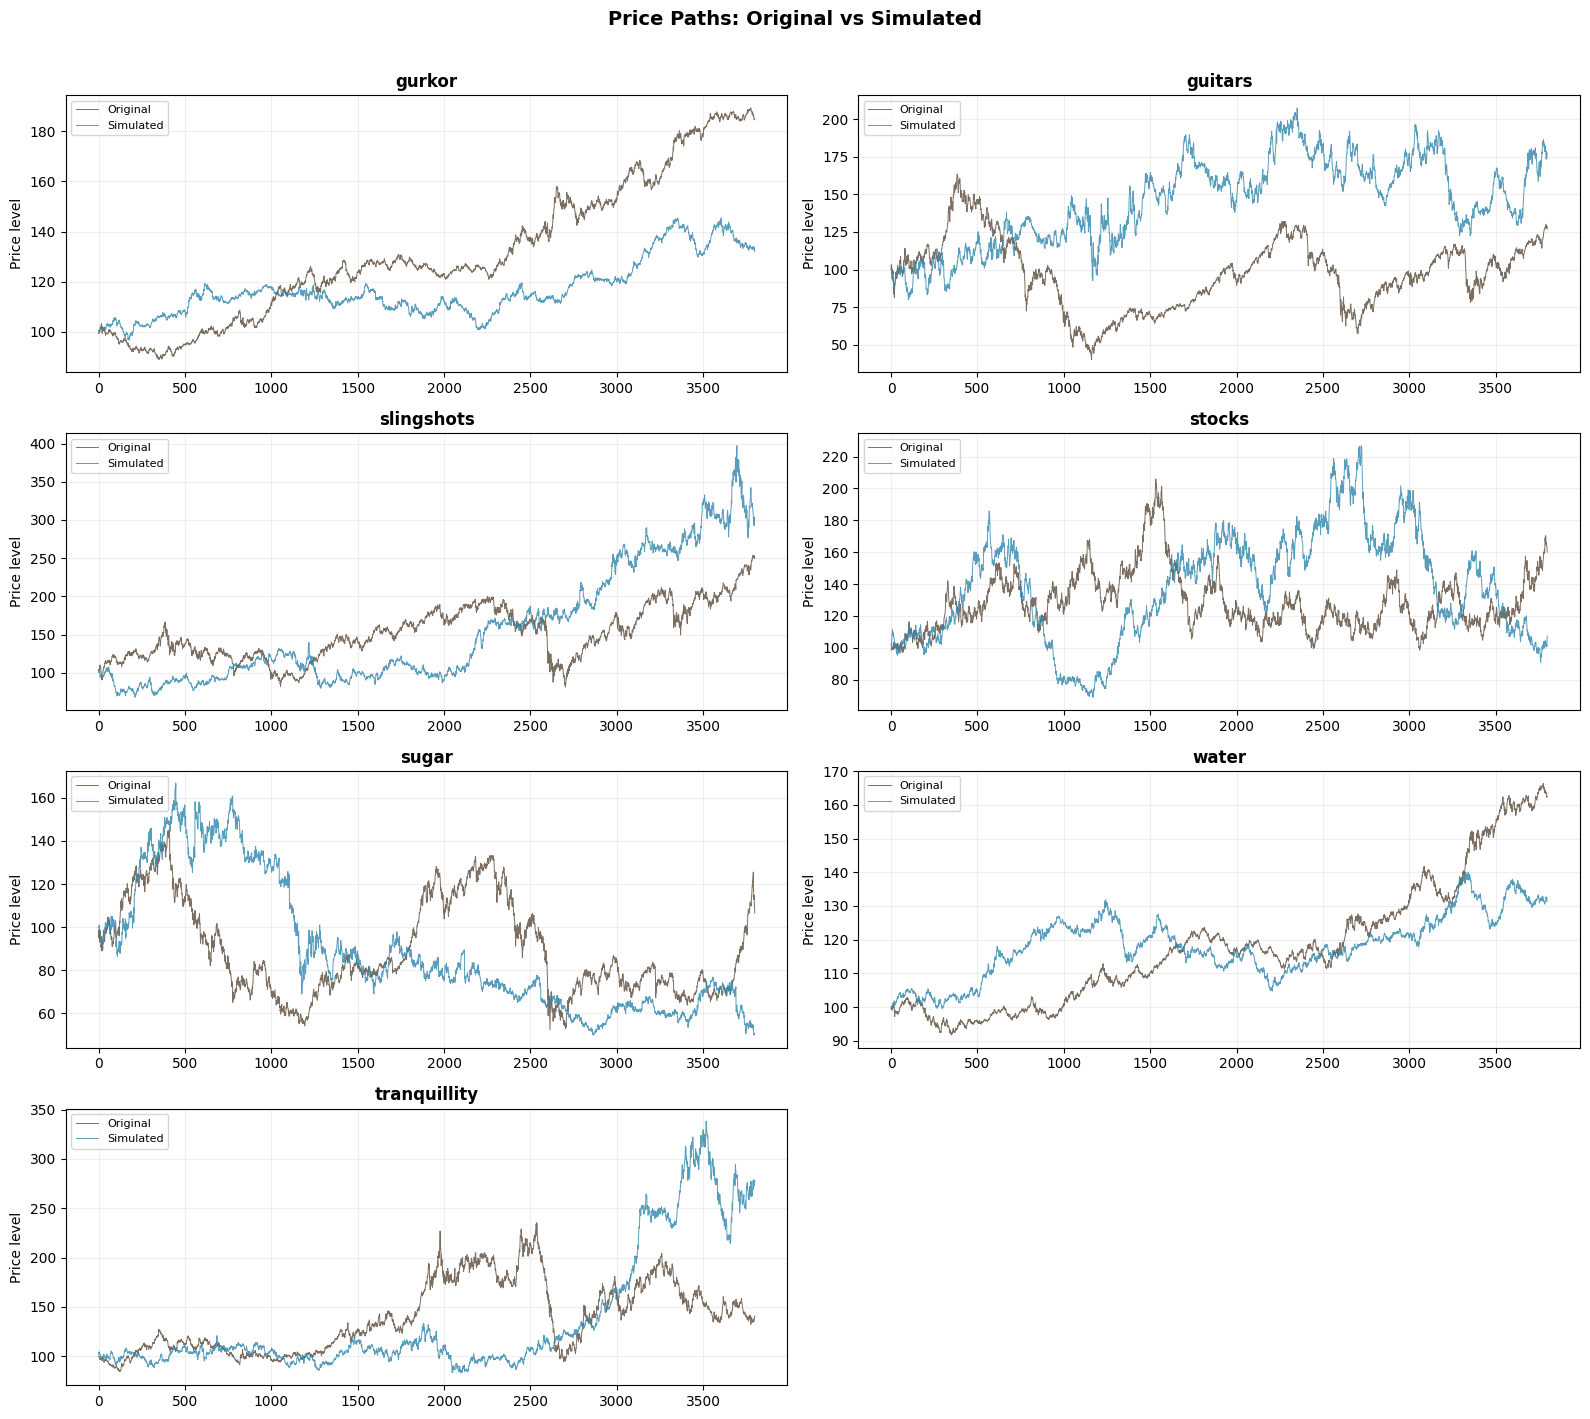

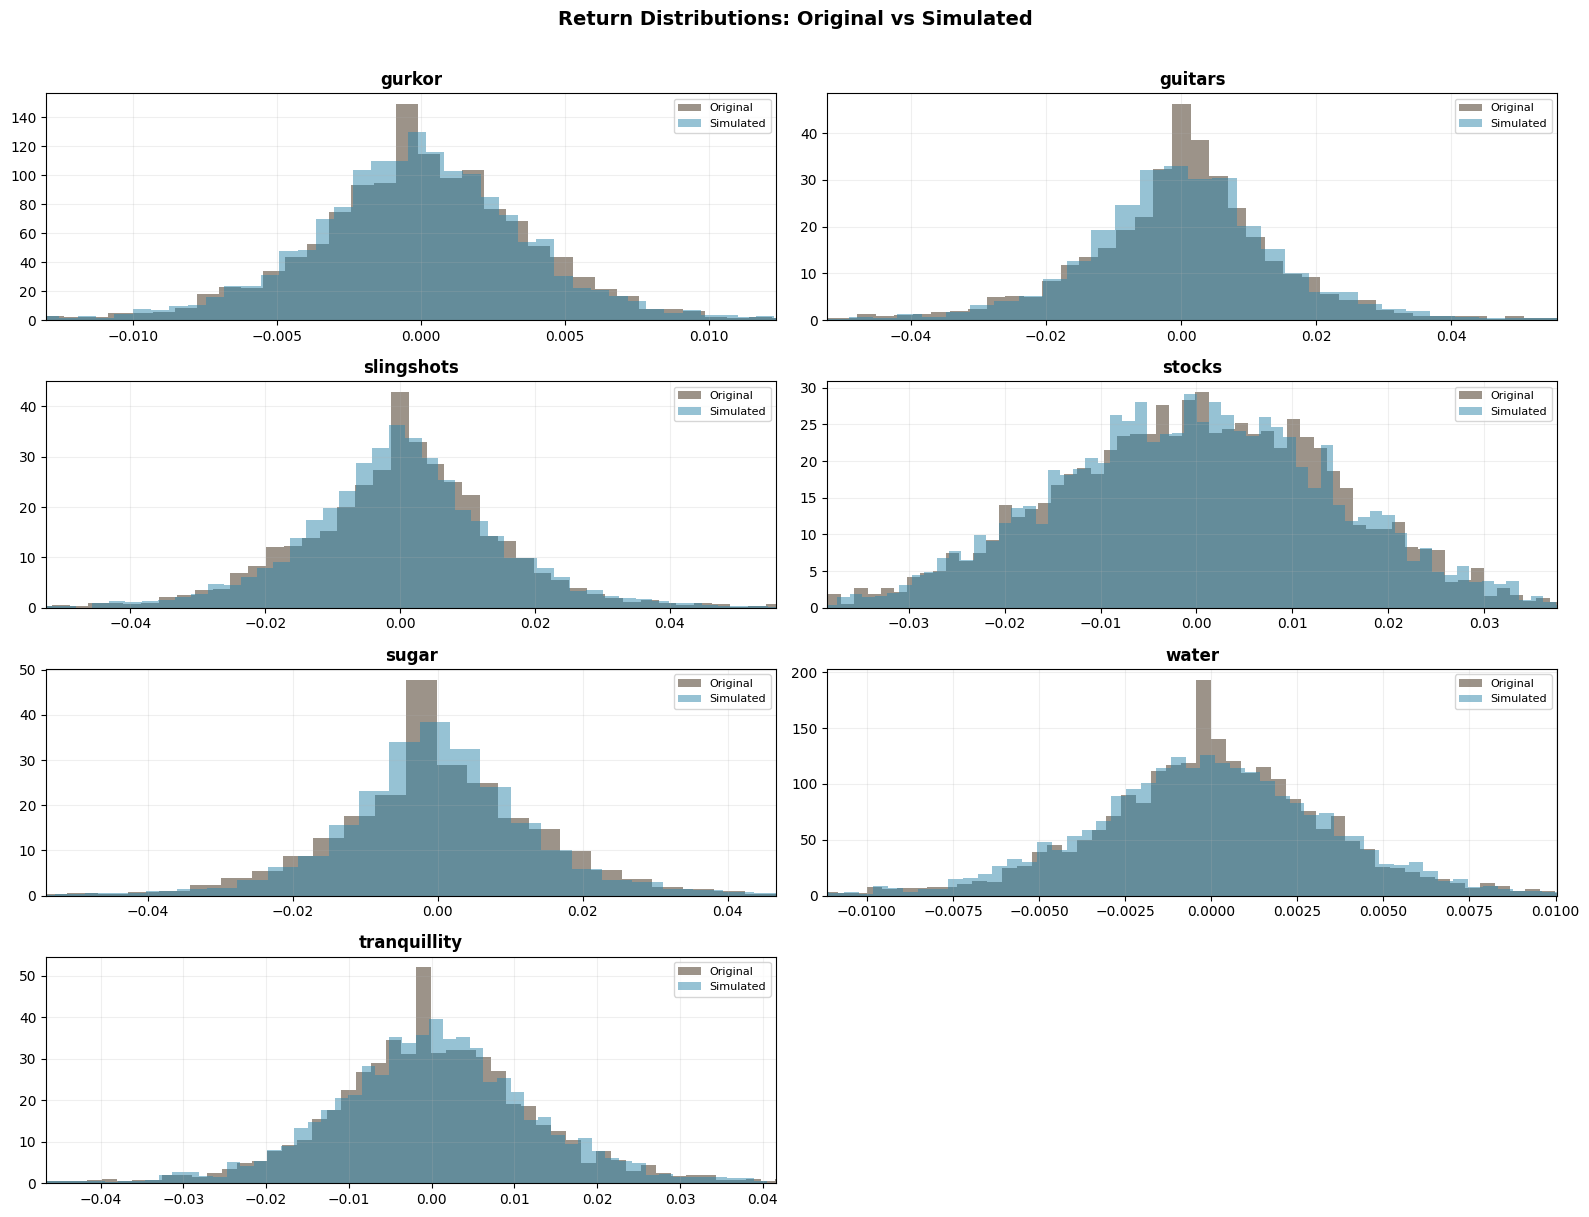

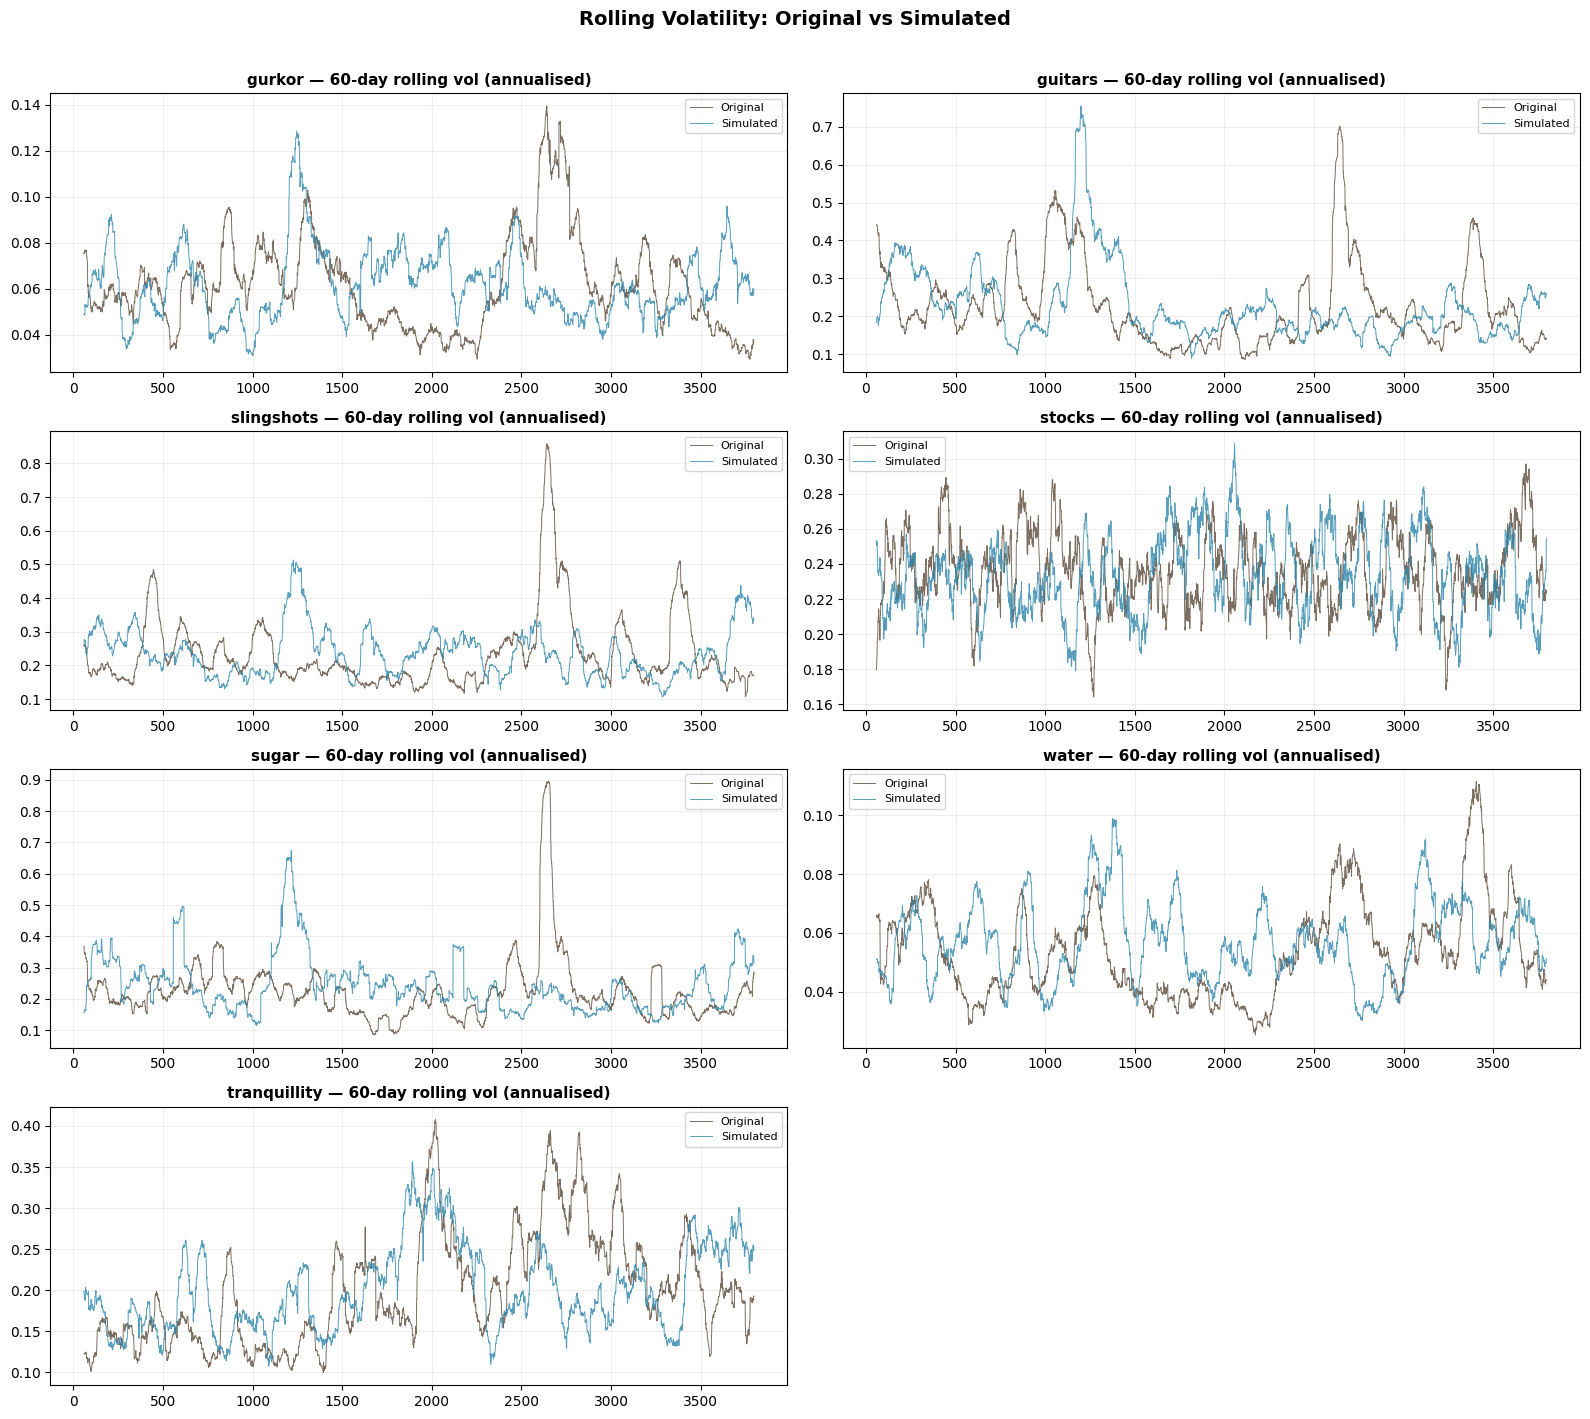

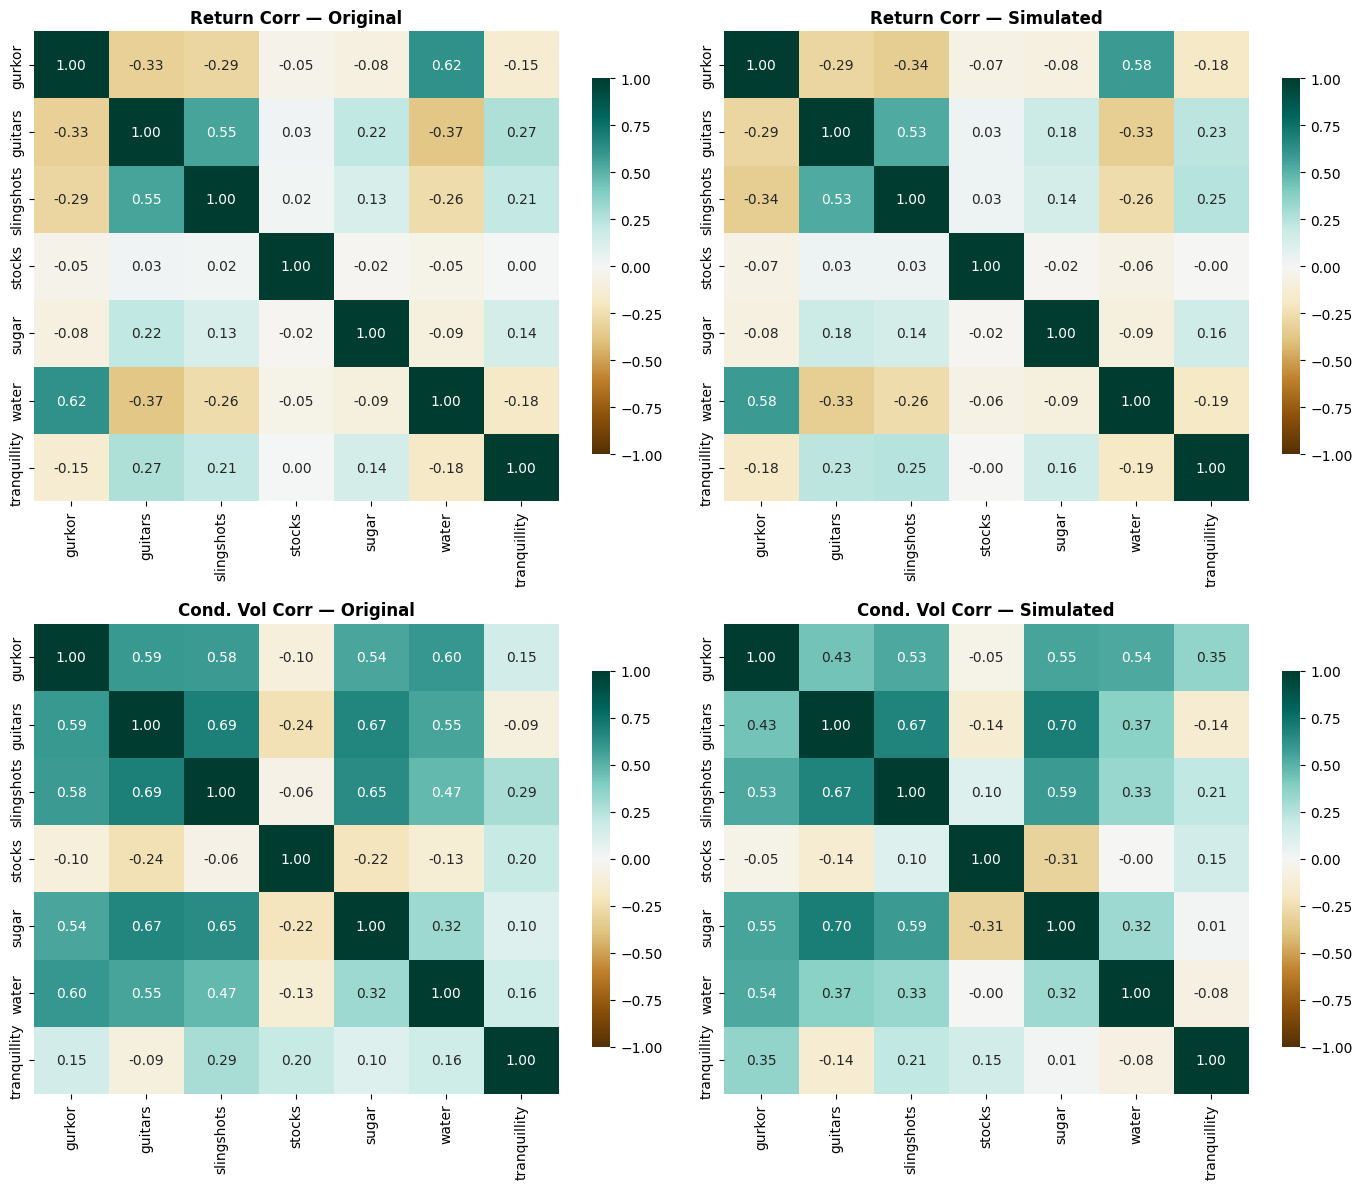

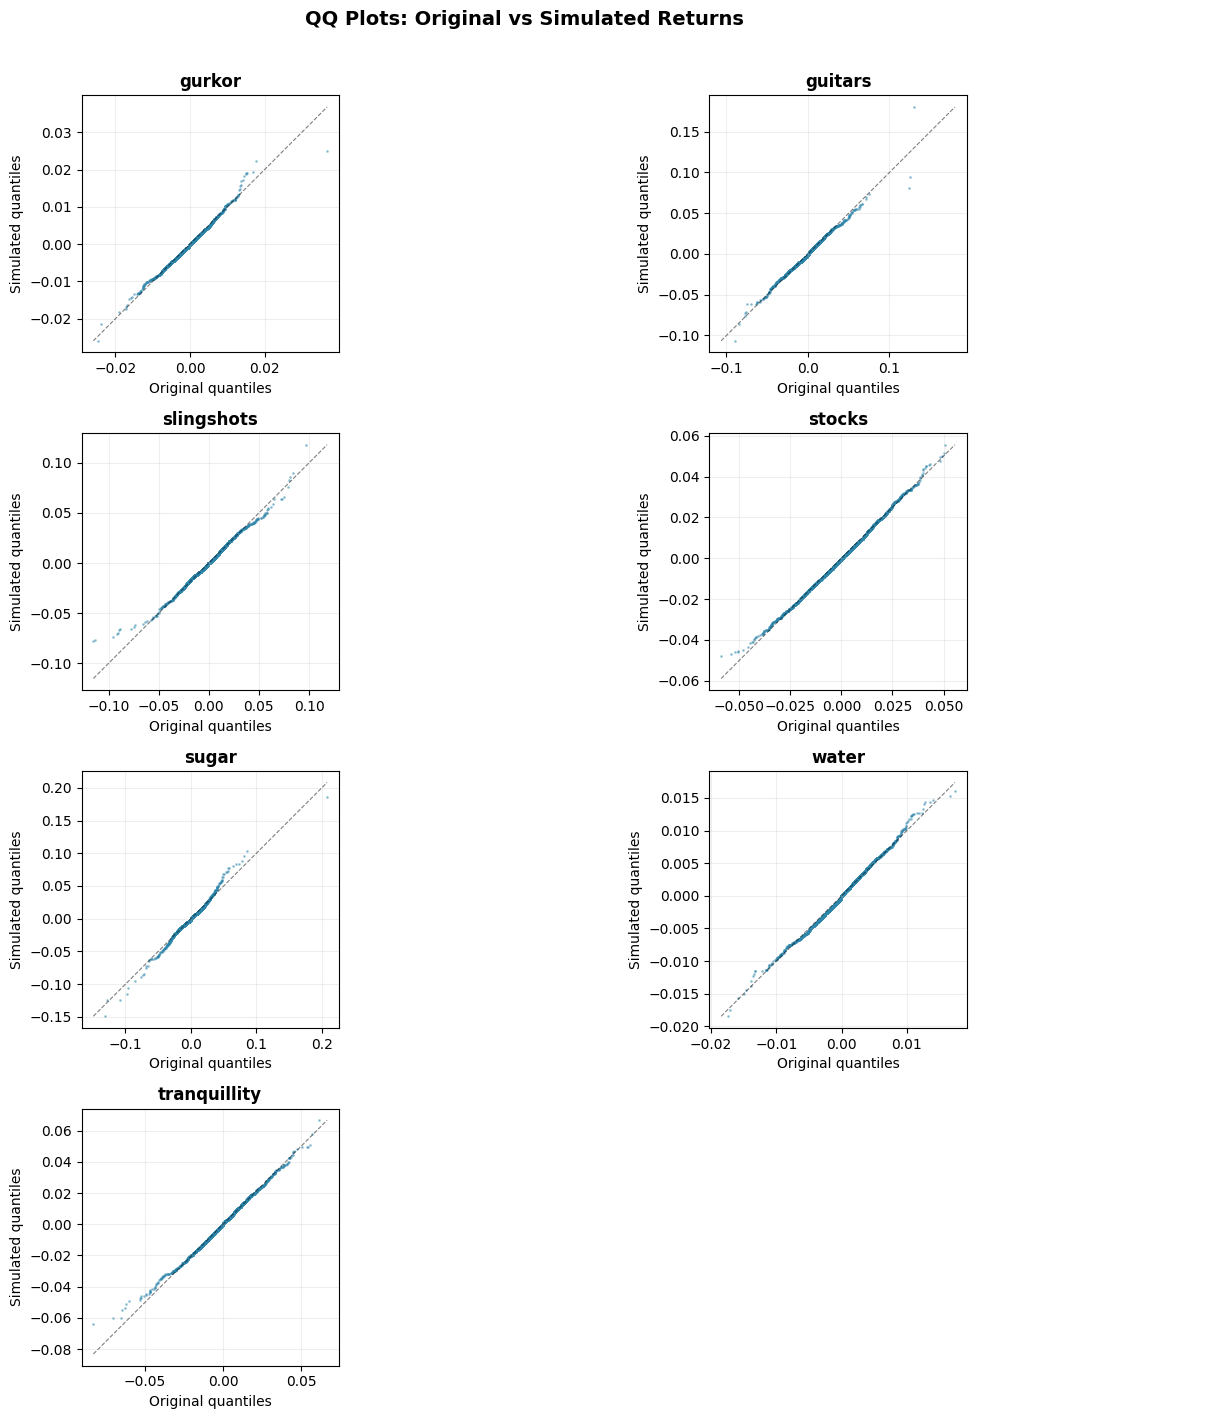

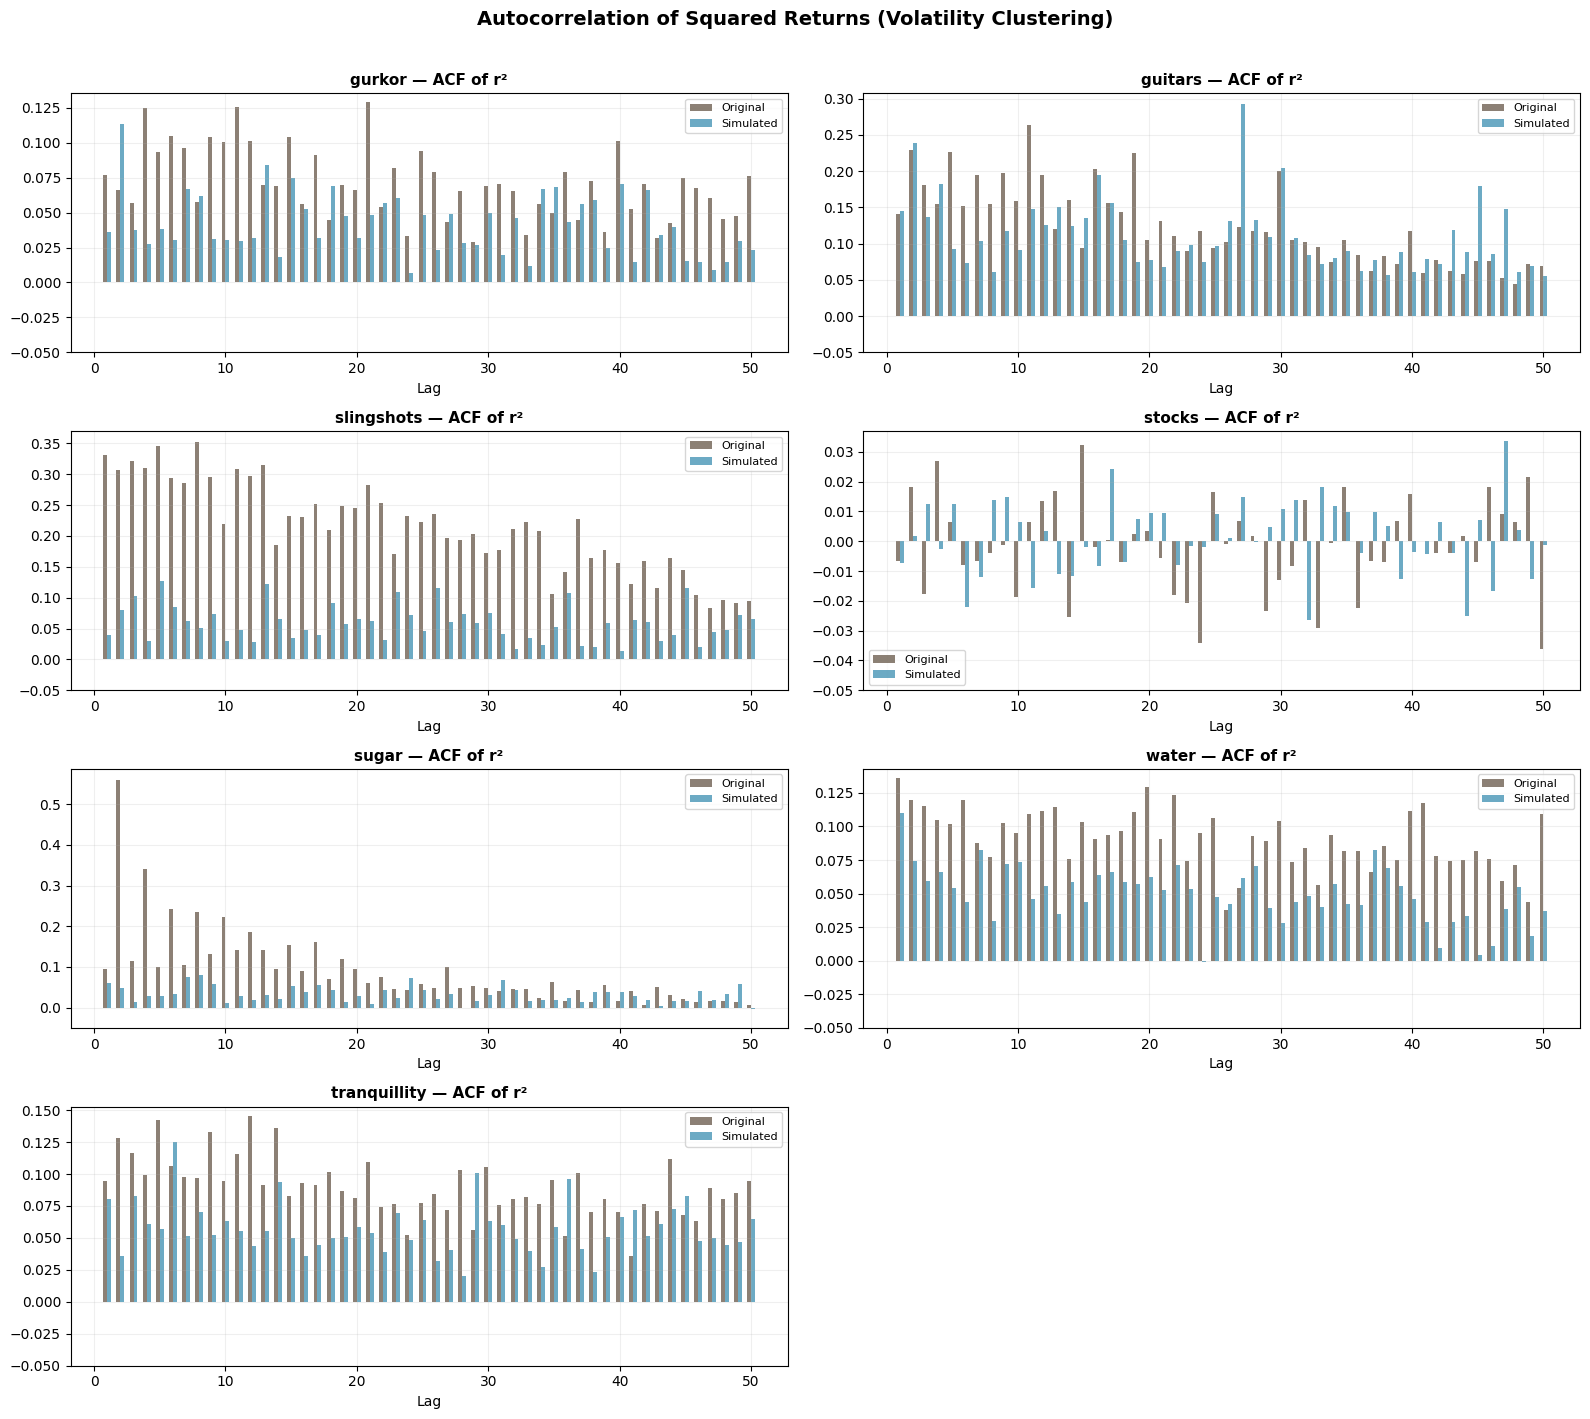

COMPREHENSIVE SUMMARY TABLE
              Mean (og) Mean (sim) Std (og) Std (sim) Skew (og) Skew (sim) Kurt (og) Kurt (sim) KS stat    KS p
Series                                                                                                         
gurkor        -0.000000  -0.000089  0.00407   0.00400     -0.06       0.10      3.62       2.85  0.0511  0.0001
guitars       -0.000000   0.000081  0.01602   0.01563      0.21       0.32      5.75       7.68  0.0474  0.0004
slingshots     0.000000   0.000038  0.01635   0.01570     -0.21       0.10      4.70       3.39  0.0397  0.0049
stocks         0.000000  -0.000106  0.01487   0.01479     -0.09       0.05      0.05      -0.03  0.0205  0.3999
sugar         -0.000000  -0.000188  0.01578   0.01634      0.03      -0.06     13.47      12.91  0.0590  0.0000
water          0.000000  -0.000056  0.00353   0.00369     -0.14       0.02      1.64       1.20  0.0413  0.0030
tranquillity   0.000000   0.000176  0.01333   0.01307     -0.20      -0.02  

In [2]:
# =============================================================================
# COMPREHENSIVE VALIDATION CELL
# Uses df_returns_final from the main simulation (no re-simulation)
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp, pearsonr
from arch import arch_model

THEME = 'BrBG'

# Use the simulation from cell 1, trimmed to original length
df_sim_real = df_returns_final.iloc[1450:1450+len(df_og_returns)].copy()
df_sim_real.index = df_og_returns.index[:len(df_sim_real)]

# Cumulate to price levels (starting at 100)
df_og_prices = (1 + df_og_returns + original_mean).cumprod() * 100
df_sim_prices = (1 + df_sim_real + original_mean).cumprod() * 100

# =============================================================================
# FIGURE 1: Side-by-side price paths
# =============================================================================
fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=False)
axes = axes.flatten()
for i, col in enumerate(var_names):
    ax = axes[i]
    ax.plot(df_og_prices[col].values, color='#5B4B3A', alpha=0.8, lw=0.7, label='Original')
    ax.plot(df_sim_prices[col].values, color='#2E86AB', alpha=0.8, lw=0.7, label='Simulated')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_ylabel('Price level')
    ax.grid(alpha=0.2)
if len(var_names) < 8:
    axes[-1].axis('off')
fig.suptitle('Price Paths: Original vs Simulated', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('price_paths_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# FIGURE 2: Return distributions (overlaid histograms)
# =============================================================================
fig, axes = plt.subplots(4, 2, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(var_names):
    ax = axes[i]
    ax.hist(df_og_returns[col].values, bins=80, density=True, alpha=0.6,
            color='#5B4B3A', label='Original', edgecolor='none')
    ax.hist(df_sim_real[col].values, bins=80, density=True, alpha=0.5,
            color='#2E86AB', label='Simulated', edgecolor='none')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlim(np.percentile(df_og_returns[col].dropna(), [0.5, 99.5]))
    ax.grid(alpha=0.2)
if len(var_names) < 8:
    axes[-1].axis('off')
fig.suptitle('Return Distributions: Original vs Simulated', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# FIGURE 3: Rolling volatility comparison
# =============================================================================
window = 60
roll_og = df_og_returns.rolling(window).std() * np.sqrt(252)
roll_sim = df_sim_real.rolling(window).std() * np.sqrt(252)

fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(var_names):
    ax = axes[i]
    ax.plot(roll_og[col].values, color='#5B4B3A', alpha=0.8, lw=0.7, label='Original')
    ax.plot(roll_sim[col].values, color='#2E86AB', alpha=0.8, lw=0.7, label='Simulated')
    ax.set_title(f'{col} — {window}-day rolling vol (annualised)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
if len(var_names) < 8:
    axes[-1].axis('off')
fig.suptitle('Rolling Volatility: Original vs Simulated', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('rolling_vol_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# FIGURE 4: Correlation heatmaps (returns + vol) — 2x2
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

sns.heatmap(df_og_returns.corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[0, 0], vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
axes[0, 0].set_title('Return Corr — Original', fontweight='bold')
sns.heatmap(df_sim_real.corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[0, 1], vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
axes[0, 1].set_title('Return Corr — Simulated', fontweight='bold')

cv_og = pd.DataFrame(index=df_og_returns.index, dtype=float)
cv_sim = pd.DataFrame(index=range(len(df_sim_real)), dtype=float)
for col in var_names:
    r1 = arch_model(df_og_returns[col]*1000, vol='Garch', p=1, q=1, mean='Zero').fit(disp='off')
    cv_og[col] = r1.conditional_volatility**2
    r2 = arch_model(df_sim_real[col]*1000, vol='Garch', p=1, q=1, mean='Zero').fit(disp='off')
    cv_sim[col] = r2.conditional_volatility**2

sns.heatmap(np.log(cv_og).corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[1, 0], vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
axes[1, 0].set_title('Cond. Vol Corr — Original', fontweight='bold')
sns.heatmap(np.log(cv_sim).corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[1, 1], vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
axes[1, 1].set_title('Cond. Vol Corr — Simulated', fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_heatmaps_4panel.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# FIGURE 5: QQ plots per series
# =============================================================================
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()
for i, col in enumerate(var_names):
    ax = axes[i]
    og_sorted = np.sort(df_og_returns[col].dropna().values)
    sim_sorted = np.sort(df_sim_real[col].values)
    n = min(len(og_sorted), len(sim_sorted))
    q_og = np.quantile(og_sorted, np.linspace(0, 1, n))
    q_sim = np.quantile(sim_sorted, np.linspace(0, 1, n))
    ax.scatter(q_og, q_sim, s=1, alpha=0.4, color='#2E86AB')
    lims = [min(q_og.min(), q_sim.min()), max(q_og.max(), q_sim.max())]
    ax.plot(lims, lims, 'k--', lw=0.8, alpha=0.5)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Original quantiles')
    ax.set_ylabel('Simulated quantiles')
    ax.grid(alpha=0.2)
    ax.set_aspect('equal')
if len(var_names) < 8:
    axes[-1].axis('off')
fig.suptitle('QQ Plots: Original vs Simulated Returns', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('qq_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# FIGURE 6: ACF of squared returns
# =============================================================================
max_lag = 50
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(var_names):
    ax = axes[i]
    og_sq = (df_og_returns[col]**2).dropna()
    sim_sq = df_sim_real[col]**2

    acf_og = [og_sq.autocorr(lag=l) for l in range(1, max_lag+1)]
    acf_sim = [sim_sq.autocorr(lag=l) for l in range(1, max_lag+1)]

    ax.bar(np.arange(1, max_lag+1) - 0.15, acf_og, width=0.3, alpha=0.7,
           color='#5B4B3A', label='Original')
    ax.bar(np.arange(1, max_lag+1) + 0.15, acf_sim, width=0.3, alpha=0.7,
           color='#2E86AB', label='Simulated')
    ax.set_title(f'{col} — ACF of r²', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel('Lag')
    ax.grid(alpha=0.2)
    ax.set_ylim(bottom=-0.05)
if len(var_names) < 8:
    axes[-1].axis('off')
fig.suptitle('Autocorrelation of Squared Returns (Volatility Clustering)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('acf_squared_returns.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# Summary statistics table
# =============================================================================
print("=" * 80)
print("COMPREHENSIVE SUMMARY TABLE")
print("=" * 80)

summary_rows = []
for col in var_names:
    og = df_og_returns[col].dropna()
    sim = df_sim_real[col]

    ks_stat, ks_p = ks_2samp(og.values, sim.values)

    summary_rows.append({
        'Series': col,
        'Mean (og)': f'{og.mean():.6f}',
        'Mean (sim)': f'{sim.mean():.6f}',
        'Std (og)': f'{og.std():.5f}',
        'Std (sim)': f'{sim.std():.5f}',
        'Skew (og)': f'{og.skew():.2f}',
        'Skew (sim)': f'{sim.skew():.2f}',
        'Kurt (og)': f'{og.kurt():.2f}',
        'Kurt (sim)': f'{sim.kurt():.2f}',
        'KS stat': f'{ks_stat:.4f}',
        'KS p': f'{ks_p:.4f}',
    })

df_summary = pd.DataFrame(summary_rows).set_index('Series')
print(df_summary.to_string())

# Correlation error summary
print("\n" + "=" * 80)
print("CORRELATION ERROR SUMMARY")
print("=" * 80)
mask = ~np.eye(7, dtype=bool)
og_rc = df_og_returns.corr().values
sim_rc = df_sim_real.corr().values
og_vc = np.log(cv_og).corr().values
sim_vc2 = np.log(cv_sim).corr().values

print(f"Return correlation MAE:     {np.mean(np.abs(og_rc[mask] - sim_rc[mask])):.4f}")
print(f"Return correlation max err: {np.max(np.abs(og_rc[mask] - sim_rc[mask])):.4f}")
print(f"Vol correlation MAE:        {np.mean(np.abs(og_vc[mask] - sim_vc2[mask])):.4f}")
print(f"Vol correlation max err:    {np.max(np.abs(og_vc[mask] - sim_vc2[mask])):.4f}")

print("\nLargest vol correlation errors:")
errs = []
for i in range(7):
    for j in range(i+1, 7):
        errs.append((var_names[i], var_names[j], og_vc[i,j], sim_vc2[i,j], og_vc[i,j]-sim_vc2[i,j]))
errs.sort(key=lambda x: abs(x[4]), reverse=True)
for a, b, ov, sv, e in errs[:10]:
    print(f"  {a:>12s} - {b:<12s}: orig={ov:+.2f}  sim={sv:+.2f}  err={e:+.3f}")

  Vol PC1: fitted_phi=0.9942, boosted_phi=0.9990
  Vol PC2: fitted_phi=0.9929, boosted_phi=0.9990
  Vol PC3: fitted_phi=0.9866, boosted_phi=0.9990
  Vol PC4: fitted_phi=0.9836, boosted_phi=0.9984
  Vol PC5: fitted_phi=0.9536, boosted_phi=0.9679
  Vol PC6: fitted_phi=0.9617, boosted_phi=0.9761

Stocks vol R² from shared factors: 0.122
Stocks coupling boost: 5x, idio scale: 0.107
  Stocks idio vol: fitted_phi=0.9716, boosted_phi=0.9911



VALIDATION

Correlation matrix comparison:
Original:
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor         1.000   -0.326      -0.291  -0.045 -0.081  0.623        -0.148
guitars       -0.326    1.000       0.553   0.028  0.216 -0.369         0.269
slingshots    -0.291    0.553       1.000   0.018  0.127 -0.259         0.210
stocks        -0.045    0.028       0.018   1.000 -0.021 -0.050         0.002
sugar         -0.081    0.216       0.127  -0.021  1.000 -0.091         0.142
water          0.623   -0.369      -0.259  -0.050 -0.091  1.000        -0.180
tranquillity  -0.148    0.269       0.210   0.002  0.142 -0.180         1.000

Simulated:
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor         1.000   -0.296      -0.298  -0.043 -0.085  0.597        -0.150
guitars       -0.296    1.000       0.507   0.017  0.220 -0.339         0.229
slingshots    -0.298    0.507       1.000   0.010  0.147 -0.252         0.22

Original:
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor          1.00     0.59        0.58   -0.10   0.54   0.60          0.15
guitars         0.59     1.00        0.69   -0.24   0.67   0.55         -0.09
slingshots      0.58     0.69        1.00   -0.06   0.65   0.47          0.29
stocks         -0.10    -0.24       -0.06    1.00  -0.22  -0.13          0.20
sugar           0.54     0.67        0.65   -0.22   1.00   0.32          0.10
water           0.60     0.55        0.47   -0.13   0.32   1.00          0.16
tranquillity    0.15    -0.09        0.29    0.20   0.10   0.16          1.00

Simulated:
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor          1.00     0.52        0.51   -0.01   0.53   0.61          0.23
guitars         0.52     1.00        0.70   -0.23   0.67   0.55         -0.08
slingshots      0.51     0.70        1.00    0.09   0.70   0.46          0.34
stocks         -0.01    -0.23        0.09 

NameError: name 'acf' is not defined

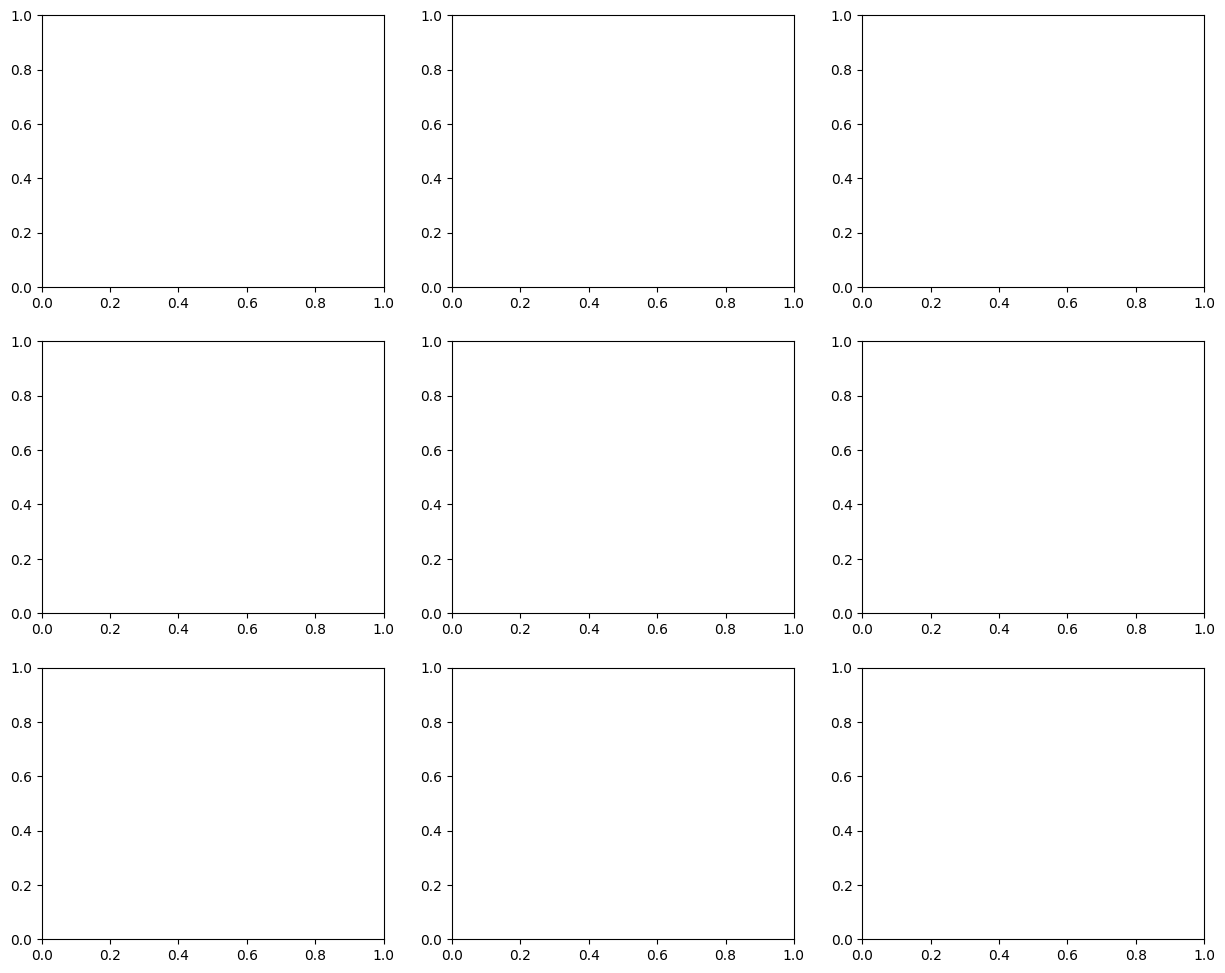

In [3]:
import numpy as np
import pandas as pd
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA
from arch import arch_model
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, t as student_t
from numpy.linalg import eigh

THEME = 'BrBG'

# =============================================================================
# Load data
# =============================================================================
df_og = pd.read_csv('../data/spiff_data-2.csv')
df_og = df_og.replace(1000, np.nan).iloc[1450:]
df_original = df_og.drop(columns=['Unnamed: 0']).set_index('day')

df_og_returns = (df_original / df_original.shift(1) - 1).dropna()
original_mean = df_og_returns.mean()
df_og_returns = df_og_returns - original_mean
original_stds = df_og_returns.std()

var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']
stocks_idx = var_names.index('stocks')
non_stock_names = [v for v in var_names if v != 'stocks']
non_stock_idx = [i for i, v in enumerate(var_names) if v != 'stocks']

# =============================================================================
# VAR(2) parameters (unchanged)
# =============================================================================
Phi1 = np.array([
    [ 0.066837, -0.047029, -0.032074, -0.129388, -0.120289, -0.162173,  0.029557],
    [ 0.123793, -0.006606,  0.033206, -0.265276, -0.075745,  0.035917, -0.058590],
    [ 0.026951,  0.015659,  0.000864, -0.045200, -0.024831,  0.035934, -0.043809],
    [ 0.199106,  0.007784,  0.014711, -0.220926, -0.061257, -0.002547,  0.039002],
    [-0.032751, -0.034423,  0.000487,  0.013779, -0.016192, -0.075896, -0.035988],
    [ 0.016032, -0.018288, -0.006550, -0.033598, -0.052375, -0.296606, -0.023336],
    [-0.014400, -0.001650,  0.021113, -0.040414,  0.006551,  0.035195, -0.182736]
])

Phi2 = np.array([
    [ 0.018276, -0.036829,  0.023368, -0.076605,  0.003404, -0.084637, -0.044700],
    [ 0.040158, -0.042788,  0.016656, -0.044778,  0.012176,  0.000934, -0.006445],
    [ 0.010401, -0.001657, -0.015511, -0.017275, -0.028722, -0.011827,  0.032037],
    [ 0.019280, -0.000785, -0.004241, -0.047150,  0.031045,  0.018171, -0.054329],
    [ 0.005180,  0.028481,  0.002092,  0.008334, -0.009077,  0.014023, -0.009718],
    [ 0.011509, -0.018017, -0.012928,  0.000614,  0.004906, -0.070937,  0.004123],
    [-0.004617,  0.034619,  0.008011, -0.010612, -0.000637,  0.029500, -0.061284]
])

# =============================================================================
# Kurtosis parameters (unchanged)
# =============================================================================
nu_obs = {
    'gurkor': 21.72, 'guitars': 18.53, 'slingshots': 32.79,
    'stocks': 401.88, 'sugar': 17.69, 'water': 22.65, 'tranquillity': 16.41
}
nu_target = {
    'gurkor': 5.66, 'guitars': 5.04, 'slingshots': 5.28,
    'stocks': 132.55, 'sugar': 4.45, 'water': 7.65, 'tranquillity': 6.31
}
alpha_blend = {
    'gurkor': 0.85, 'guitars': 0.727, 'slingshots': 1.0,
    'stocks': 0.8, 'sugar': 1.0, 'water': 0.85, 'tranquillity': 0.77,
}
nu_blended = {col: nu_obs[col] + alpha_blend[col] * (nu_target[col] - nu_obs[col]) for col in var_names}
t_scales = {col: 1.0 / np.sqrt(nu_blended[col] / (nu_blended[col] - 2)) for col in var_names}

# =============================================================================
# GARCH on original data
# =============================================================================
cond_var_og = pd.DataFrame(index=df_og_returns.index, columns=var_names, dtype=float)
original_garch_params = {}

for col in var_names:
    model = arch_model(df_og_returns[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var_og[col] = res.conditional_volatility ** 2
    original_garch_params[col] = {
        'omega': res.params['omega'],
        'alpha': res.params['alpha[1]'],
        'beta': res.params['beta[1]']
    }

# =============================================================================
# PCA on log-volatility — back to 6 PCs (your original working version)
# =============================================================================
log_h_og = np.log(cond_var_og.astype(float))
log_h_means = log_h_og.mean().values
log_h_stds = log_h_og.std().values
log_h_std = (log_h_og - log_h_means) / log_h_stds

# Use 6 PCs (explains 100% of variance, your original choice)
n_pc = 6
log_h_non_stock = log_h_std[non_stock_names]
pca = PCA(n_components=n_pc)
pca_factors_ns = pca.fit_transform(log_h_non_stock)
vol_loadings_ns = pca.components_.T  # (6, 6)

# =============================================================================
# KEY FIX: Fit AR(1) but with BOOSTED persistence to match ACF
# =============================================================================
# Instead of using fitted phi, we tune it to match the ACF of squared returns
# The original fitted values were ~0.95-0.99, but we need ~0.995-0.999
# to compensate for the exp() transformation and mixing

vol_factor_params = {}
for k in range(n_pc):
    factor = pca_factors_ns[:, k]
    X = np.column_stack((np.ones(len(factor) - 1), factor[:-1]))
    beta = np.linalg.lstsq(X, factor[1:], rcond=None)[0]
    c, phi_fitted = beta
    resid = factor[1:] - X @ beta
    
    # BOOST persistence significantly (tune this factor if needed)
    phi_boosted = min(phi_fitted * 1.015, 0.999)  # 1.5% boost, capped
    
    vol_factor_params[f'PC{k+1}'] = {
        'phi': float(phi_boosted),  # Use boosted version
        'c': float(c),
        'resid_std': float(resid.std()),
        'target_std': float(factor.std())
    }
    print(f"  Vol PC{k+1}: fitted_phi={phi_fitted:.4f}, boosted_phi={phi_boosted:.4f}")

# Stocks coupling (same as your original)
stocks_log_h = log_h_std['stocks'].values
stocks_on_shared = pca_factors_ns  # all 6 PCs
beta_stocks = np.linalg.lstsq(
    np.column_stack([np.ones(len(stocks_log_h)), stocks_on_shared]),
    stocks_log_h, rcond=None
)[0]
stocks_shared_component = np.column_stack([np.ones(len(stocks_log_h)), stocks_on_shared]) @ beta_stocks
stocks_idio = stocks_log_h - stocks_shared_component
stocks_coupling_r2 = 1 - np.var(stocks_idio) / np.var(stocks_log_h)
print(f"\nStocks vol R² from shared factors: {stocks_coupling_r2:.3f}")

# Boost stocks coupling (your original 5x)
STOCKS_COUPLING_BOOST = 5
beta_stocks_boosted = beta_stocks.copy()
beta_stocks_boosted[1:] *= STOCKS_COUPLING_BOOST

stocks_shared_boosted = np.column_stack([np.ones(len(stocks_log_h)), stocks_on_shared]) @ beta_stocks_boosted
stocks_idio_boosted = stocks_log_h - stocks_shared_boosted
var_total_original = np.var(stocks_log_h)
var_shared_boosted = np.var(stocks_shared_boosted)
var_idio_needed = max(var_total_original - var_shared_boosted, 0.01 * var_total_original)
idio_scale = np.sqrt(var_idio_needed / np.var(stocks_idio))
print(f"Stocks coupling boost: {STOCKS_COUPLING_BOOST}x, idio scale: {idio_scale:.3f}")

# Fit AR(1) to stocks idiosyncratic with BOOST
X_s = np.column_stack((np.ones(len(stocks_idio) - 1), stocks_idio[:-1]))
beta_s = np.linalg.lstsq(X_s, stocks_idio[1:], rcond=None)[0]
phi_s_fitted = beta_s[1]
phi_s_boosted = min(phi_s_fitted * 1.02, 0.999)  # 2% boost for stocks

stocks_vol_params = {
    'c': float(beta_s[0]),
    'phi': float(phi_s_boosted),  # Use boosted version
    'resid_std': float((stocks_idio[1:] - X_s @ beta_s).std(ddof=1)),
    'target_std': float(stocks_idio.std(ddof=1)),
    'coupling_betas': beta_stocks_boosted[1:].tolist(),
    'coupling_intercept': float(beta_stocks_boosted[0]),
    'idio_scale': float(idio_scale)
}
print(f"  Stocks idio vol: fitted_phi={phi_s_fitted:.4f}, boosted_phi={phi_s_boosted:.4f}")

# Return correlation structure (unchanged)
og_corr = df_og_returns.corr().values
eigenvalues, eigenvectors = eigh(og_corr)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
Lambda_corrected = eigenvectors * np.sqrt(eigenvalues)

# =============================================================================
# Simulation (your original code, unchanged structure)
# =============================================================================
np.random.seed(69)
T = 20_000
burn = 500
T_total = T + burn

# --- Shared vol factors ---
vol_factors = np.zeros((T_total, n_pc))
for k in range(n_pc):
    p = vol_factor_params[f'PC{k+1}']
    phi, c, sigma = p['phi'], p['c'], p['resid_std']
    if abs(phi) < 1:
        vol_factors[0, k] = c / (1 - phi)
    for t in range(1, T_total):
        vol_factors[t, k] = c + phi * vol_factors[t - 1, k] + sigma * np.random.randn()

# Covariance correction (your original)
target_cov = np.diag([vol_factor_params[f'PC{k+1}']['target_std'] ** 2 for k in range(n_pc)])
current_cov = np.cov(vol_factors, rowvar=False)
L_current = np.linalg.cholesky(current_cov + np.eye(n_pc) * 1e-10)
L_target = np.linalg.cholesky(target_cov)
vol_factors = vol_factors @ np.linalg.inv(L_current).T @ L_target.T

# Reconstruct non-stock log-volatilities
log_h_std_sim_ns = vol_factors @ vol_loadings_ns.T

# --- Stocks idiosyncratic vol ---
sp = stocks_vol_params
stocks_idio_sim = np.zeros(T_total)
if abs(sp['phi']) < 1:
    stocks_idio_sim[0] = sp['c'] / (1 - sp['phi'])
for t in range(1, T_total):
    stocks_idio_sim[t] = sp['c'] + sp['phi'] * stocks_idio_sim[t - 1] + sp['resid_std'] * np.random.randn()

stocks_idio_sim *= sp['target_std'] / stocks_idio_sim.std()
stocks_idio_sim *= sp.get('idio_scale', 1.0)

n_couple = len(sp['coupling_betas'])
stocks_shared_sim = sp['coupling_intercept'] + sum(
    sp['coupling_betas'][j] * vol_factors[:, j] for j in range(n_couple)
)
stocks_log_h_std_sim = stocks_shared_sim + stocks_idio_sim

# Assemble full log-volatility array
log_h_std_sim = np.zeros((T_total, 7))
ns_col = 0
for i, col in enumerate(var_names):
    if col == 'stocks':
        log_h_std_sim[:, i] = stocks_log_h_std_sim
    else:
        log_h_std_sim[:, i] = log_h_std_sim_ns[:, ns_col]
        ns_col += 1

log_h_sim = log_h_std_sim * log_h_stds + log_h_means
h_sim = np.exp(log_h_sim)

# Remove burn-in
F_sim = np.zeros((T_total, 7))
for t in range(2, T_total):
    F_sim[t] = Phi1 @ F_sim[t - 1] + Phi2 @ F_sim[t - 2] + np.random.randn(7)

F_sim = F_sim[burn:]
h_sim = h_sim[burn:]

# --- Correlated returns ---
Y_sim = F_sim @ Lambda_corrected.T
Y_sim_std = Y_sim / Y_sim.std(axis=0)
Z = Y_sim_std

Y_final = np.zeros_like(Y_sim)
for t in range(len(Y_sim)):
    uniform = norm.cdf(Z[t])
    correlated_t = np.array([
        student_t.ppf(uniform[i], df=nu_blended[col]) * t_scales[col]
        for i, col in enumerate(var_names)
    ])
    Y_final[t] = correlated_t * np.sqrt(h_sim[t])

df_returns_final = pd.DataFrame(Y_final, columns=var_names)
scale_factors = original_stds / df_returns_final.std()
df_returns_final = df_returns_final.multiply(scale_factors, axis=1)

# =============================================================================
# Validation (your original validation code)
# =============================================================================
print("\n" + "=" * 60)
print("VALIDATION")
print("=" * 60)

print("\nCorrelation matrix comparison:")
print("Original:")
print(df_og_returns.corr().round(3))
print("\nSimulated:")
print(df_returns_final.corr().round(3))

print("\nCorrelation MAE (off-diagonal):")
og_c = df_og_returns.corr().values
sim_c = df_returns_final.corr().values
mask = ~np.eye(7, dtype=bool)
print(f"  {np.mean(np.abs(og_c[mask] - sim_c[mask])):.4f}")

print("\nKurtosis comparison:")
print(pd.DataFrame({
    'Original': df_og_returns.kurt(),
    'Simulated': df_returns_final.kurt()
}).round(2))

print("\nConditional volatility correlations:")
cond_var_sim = pd.DataFrame(index=range(len(df_returns_final)), columns=var_names, dtype=float)
for col in var_names:
    res = arch_model(df_returns_final[col] * 1000, vol='Garch', p=1, q=1, mean='Zero').fit(disp='off')
    cond_var_sim[col] = res.conditional_volatility ** 2

print("Original:")
print(np.log(cond_var_og).corr().round(2))
print("\nSimulated:")
print(np.log(cond_var_sim).corr().round(2))

og_vc = np.log(cond_var_og).corr().values
sim_vc = np.log(cond_var_sim).corr().values
mae_vol = np.mean(np.abs(og_vc[mask] - sim_vc[mask]))
print(f"\nVol correlation MAE: {mae_vol:.3f}")

# Plot ACF comparison
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for idx, col in enumerate(var_names):
    ax = axes[idx]
    r2_orig = (df_og_returns[col]**2).values
    r2_sim = (df_returns_final[col]**2).values
    acf_orig = acf(r2_orig, nlags=50, fft=True)
    acf_sim = acf(r2_sim, nlags=50, fft=True)
    ax.bar(np.arange(51), acf_orig, alpha=0.6, label='Original', color='#8B4513', width=0.4)
    ax.bar(np.arange(51)+0.4, acf_sim, alpha=0.6, label='Simulated', color='#4682B4', width=0.4)
    ax.set_title(f'{col} — ACF of r²')
    ax.set_ylim(0, max(acf_orig.max(), acf_sim.max()) * 1.2)
    ax.legend()
axes[7].axis('off')
axes[8].axis('off')
plt.tight_layout()
plt.savefig('acf_comparison.png', dpi=150)
plt.show()

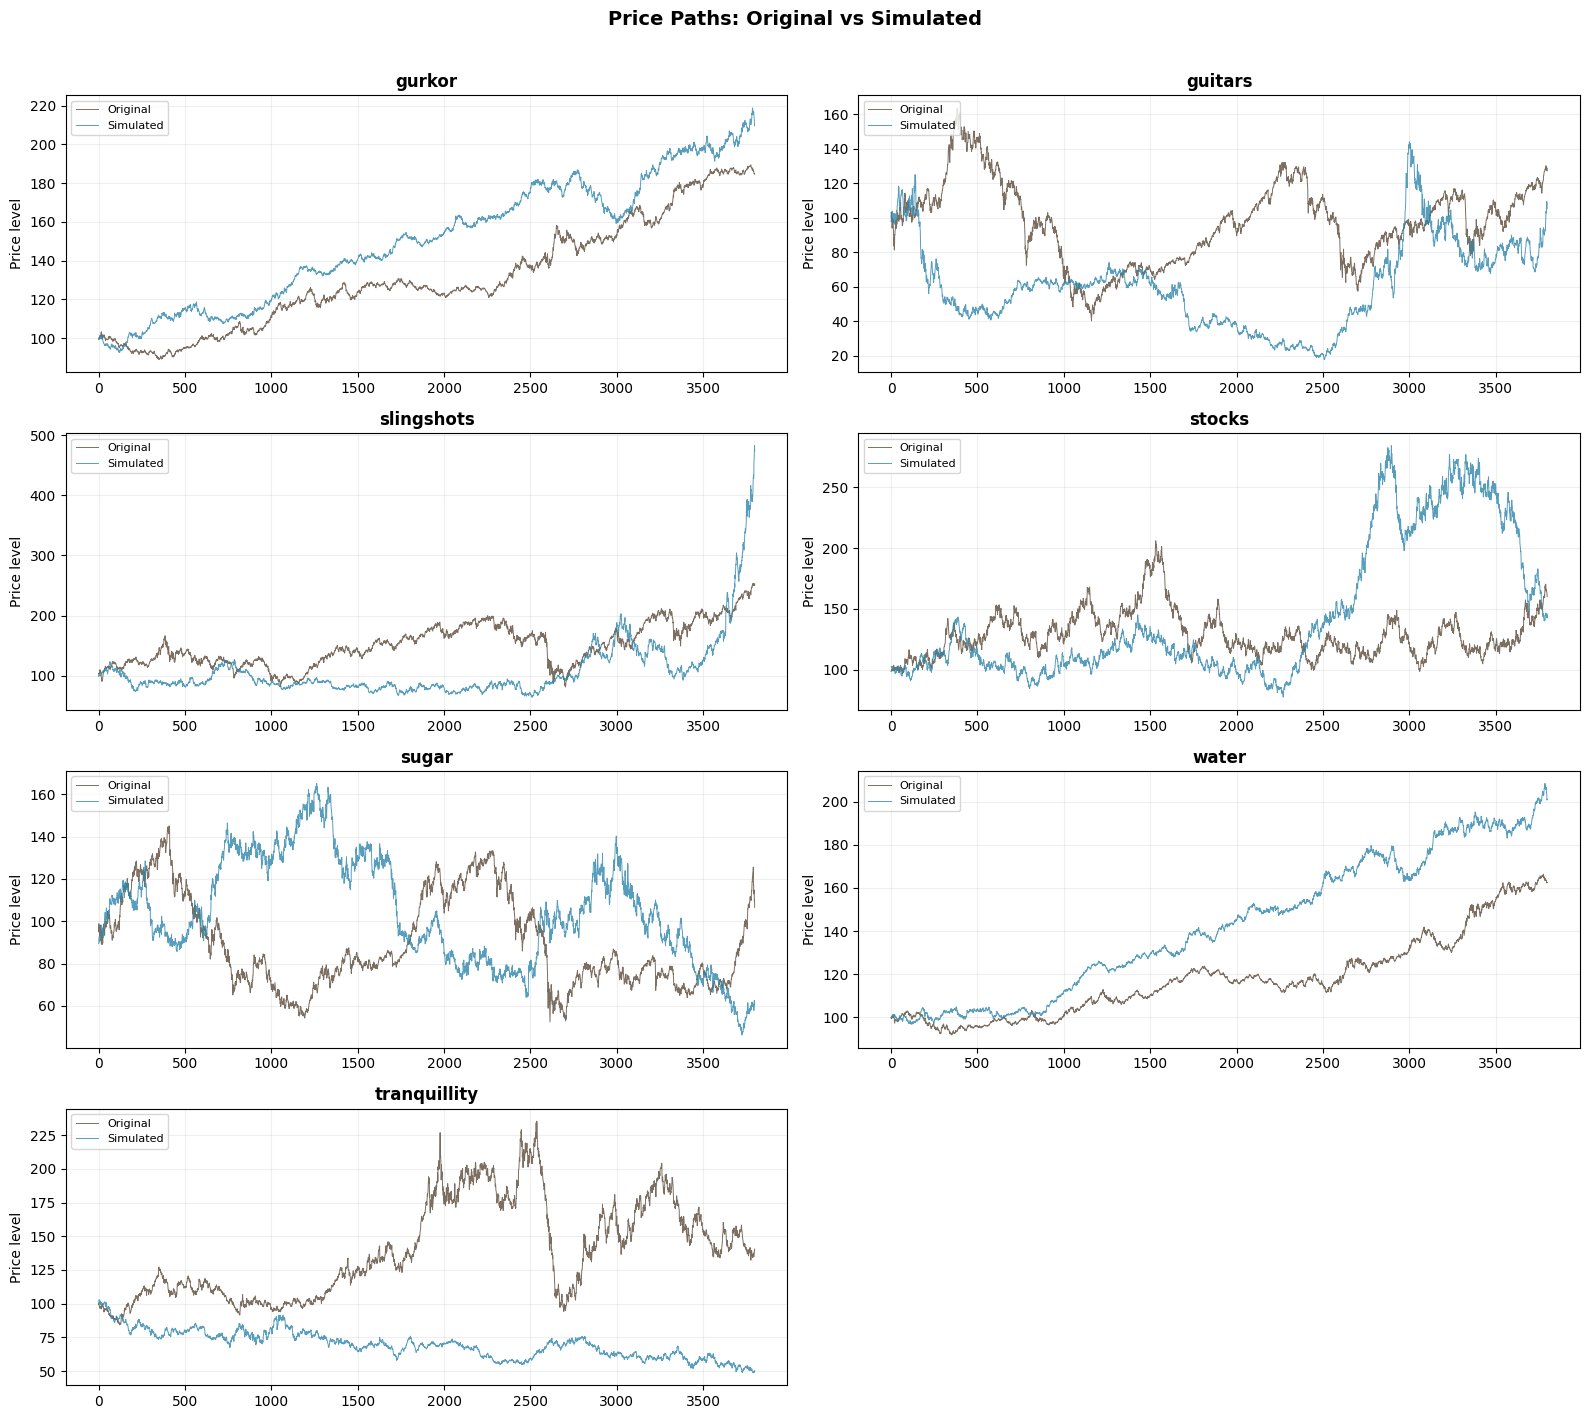

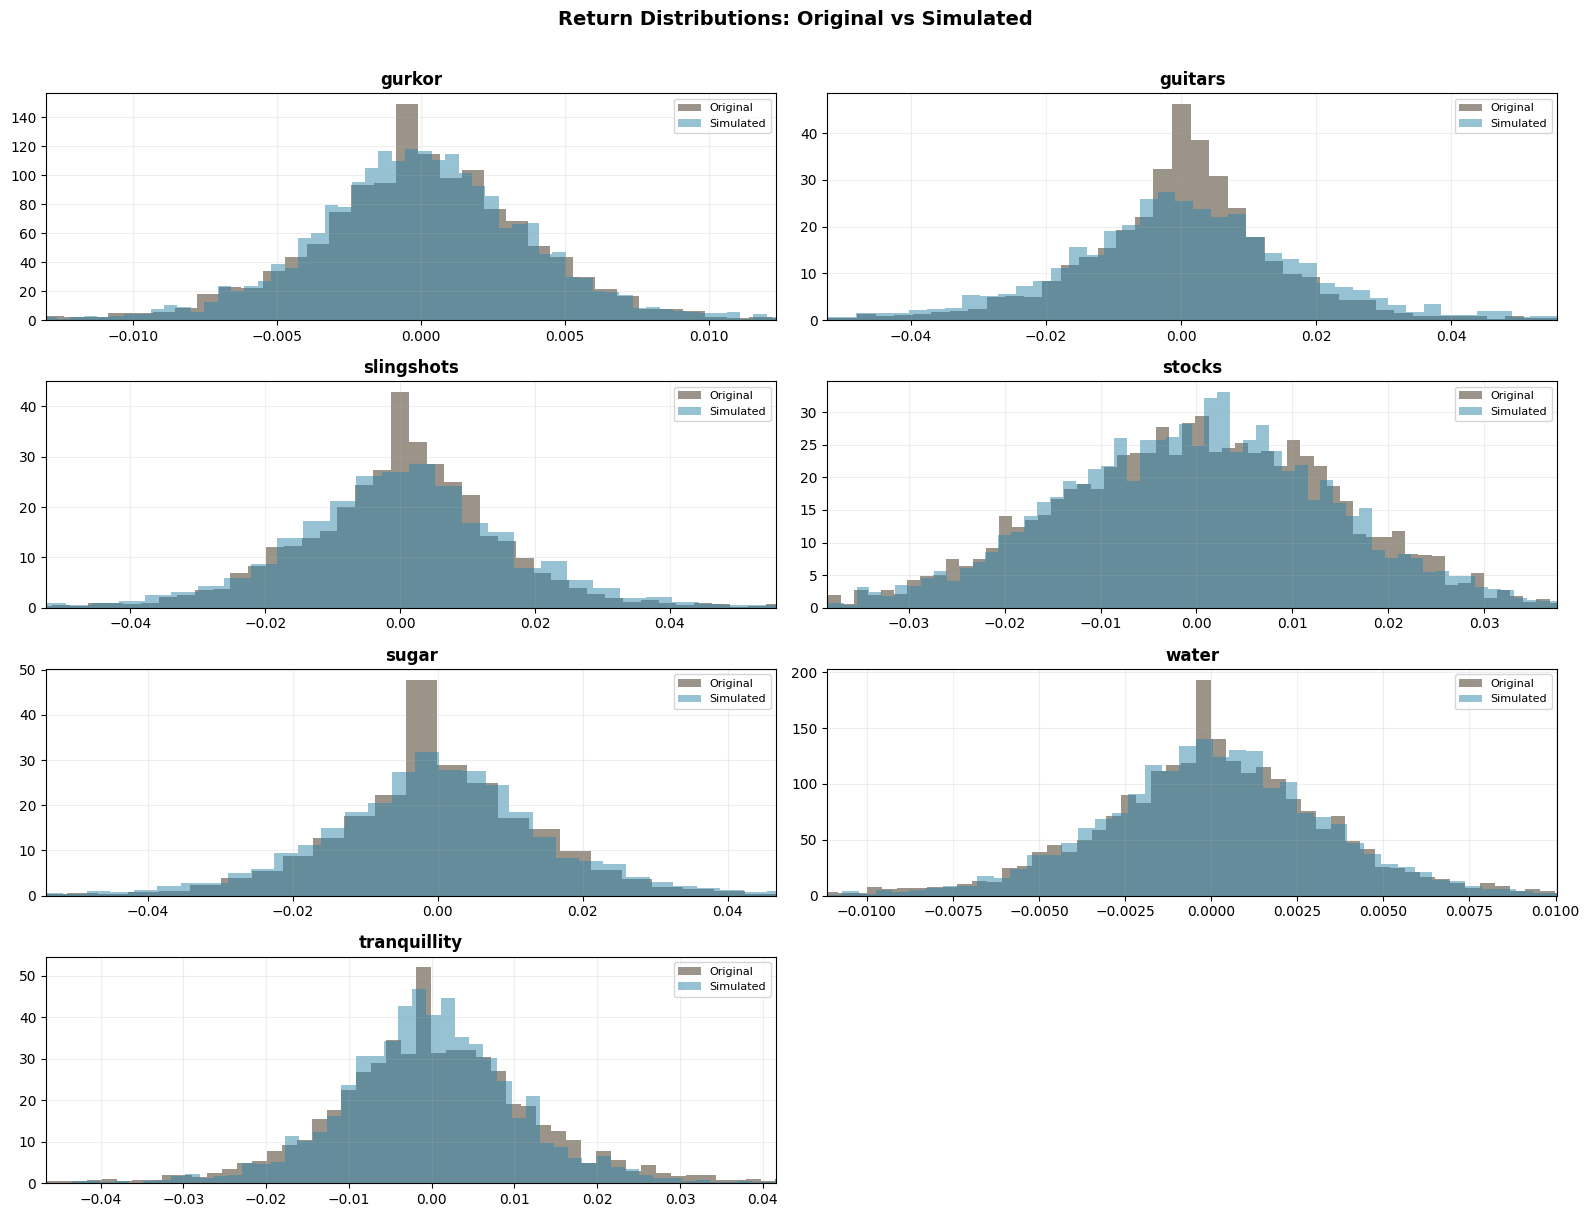

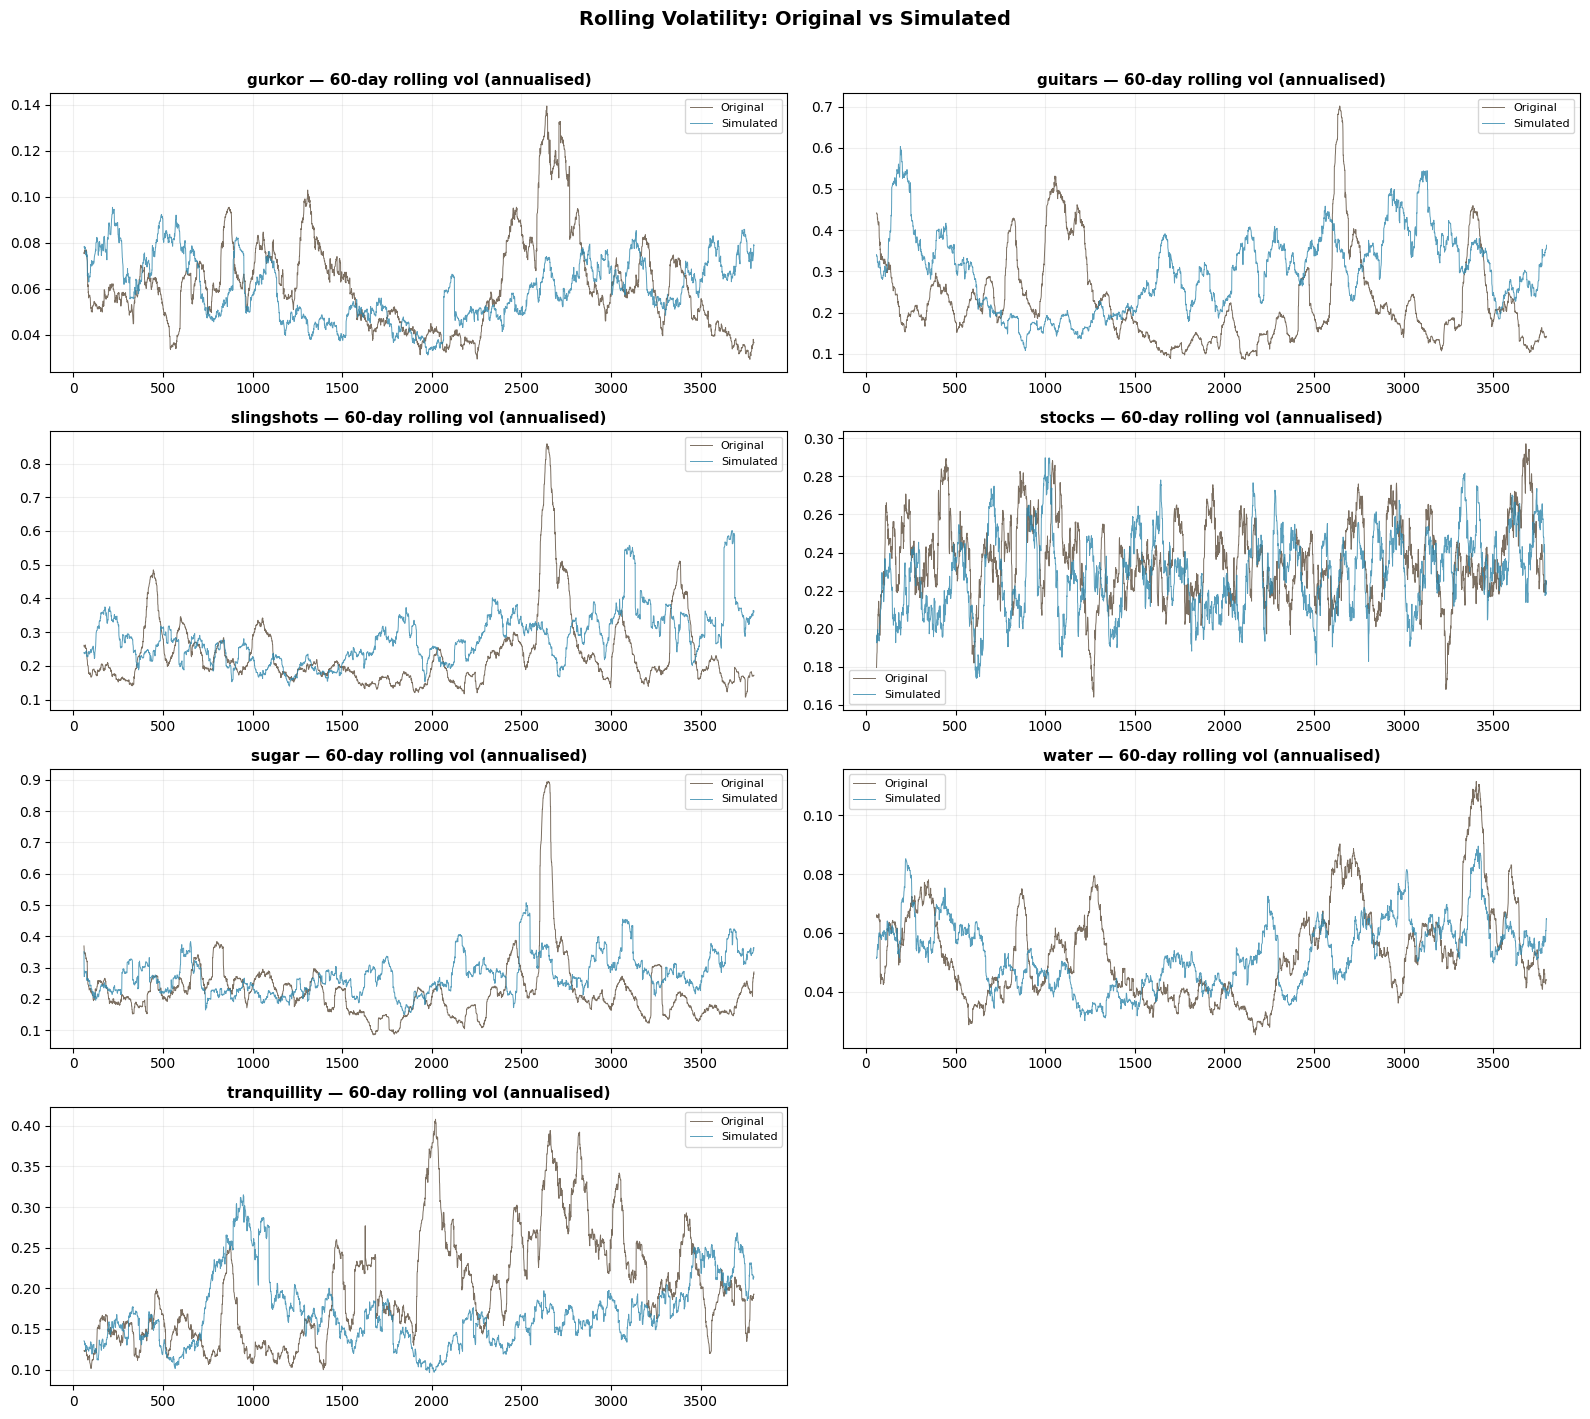

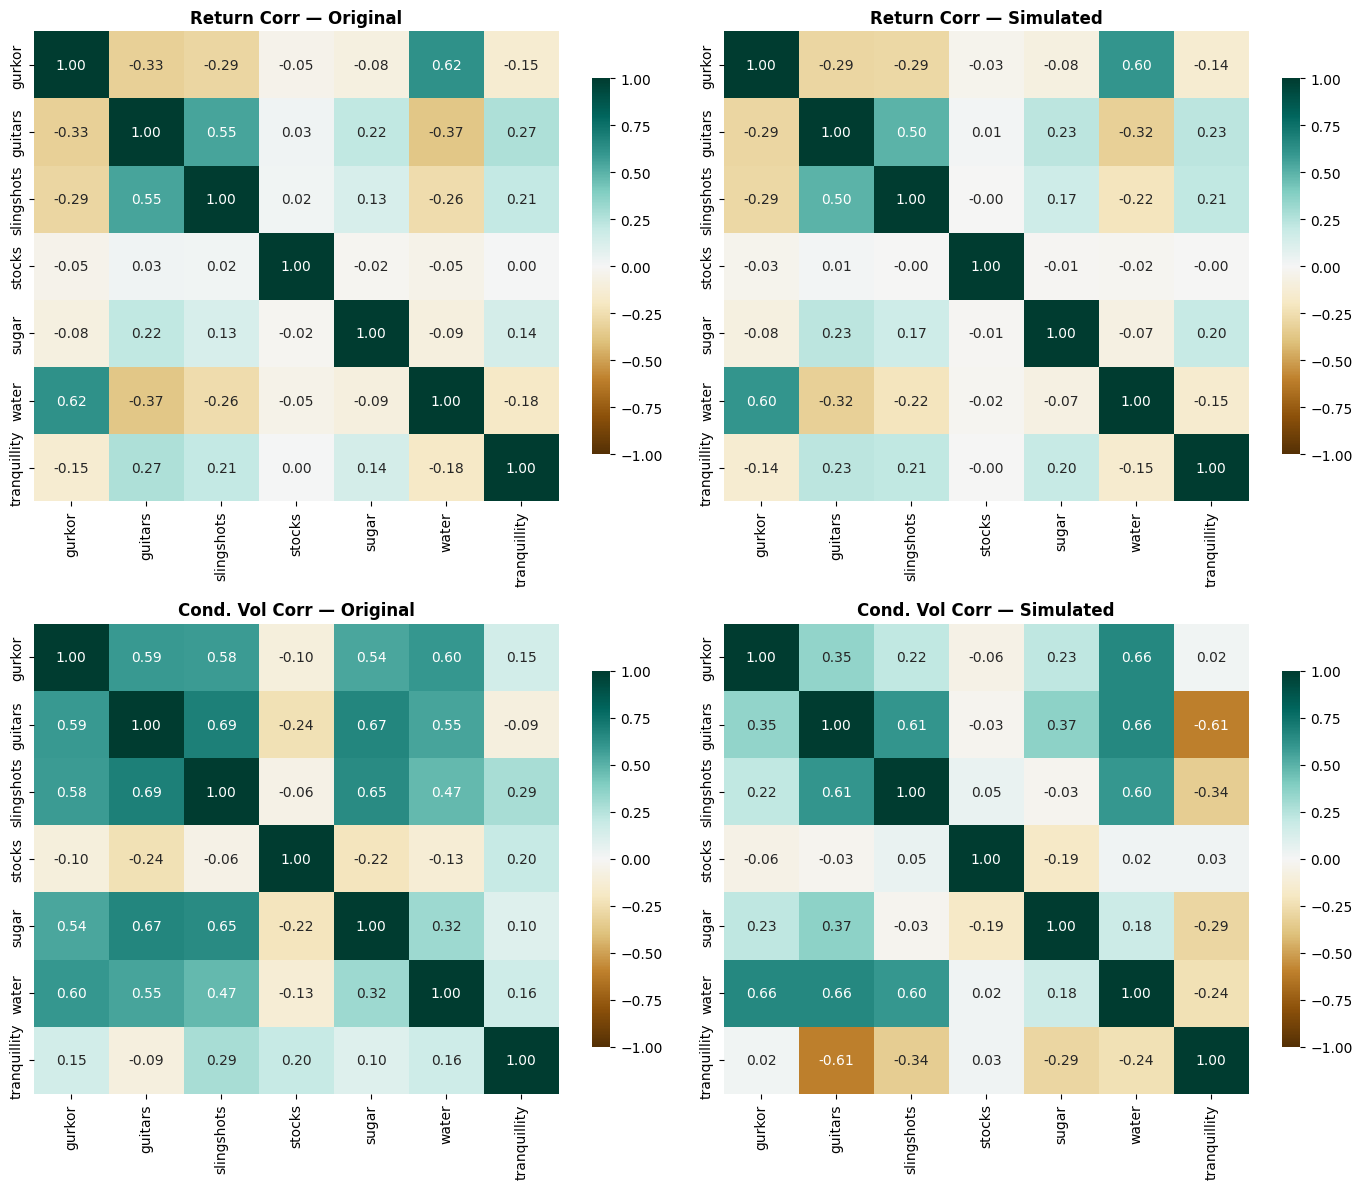

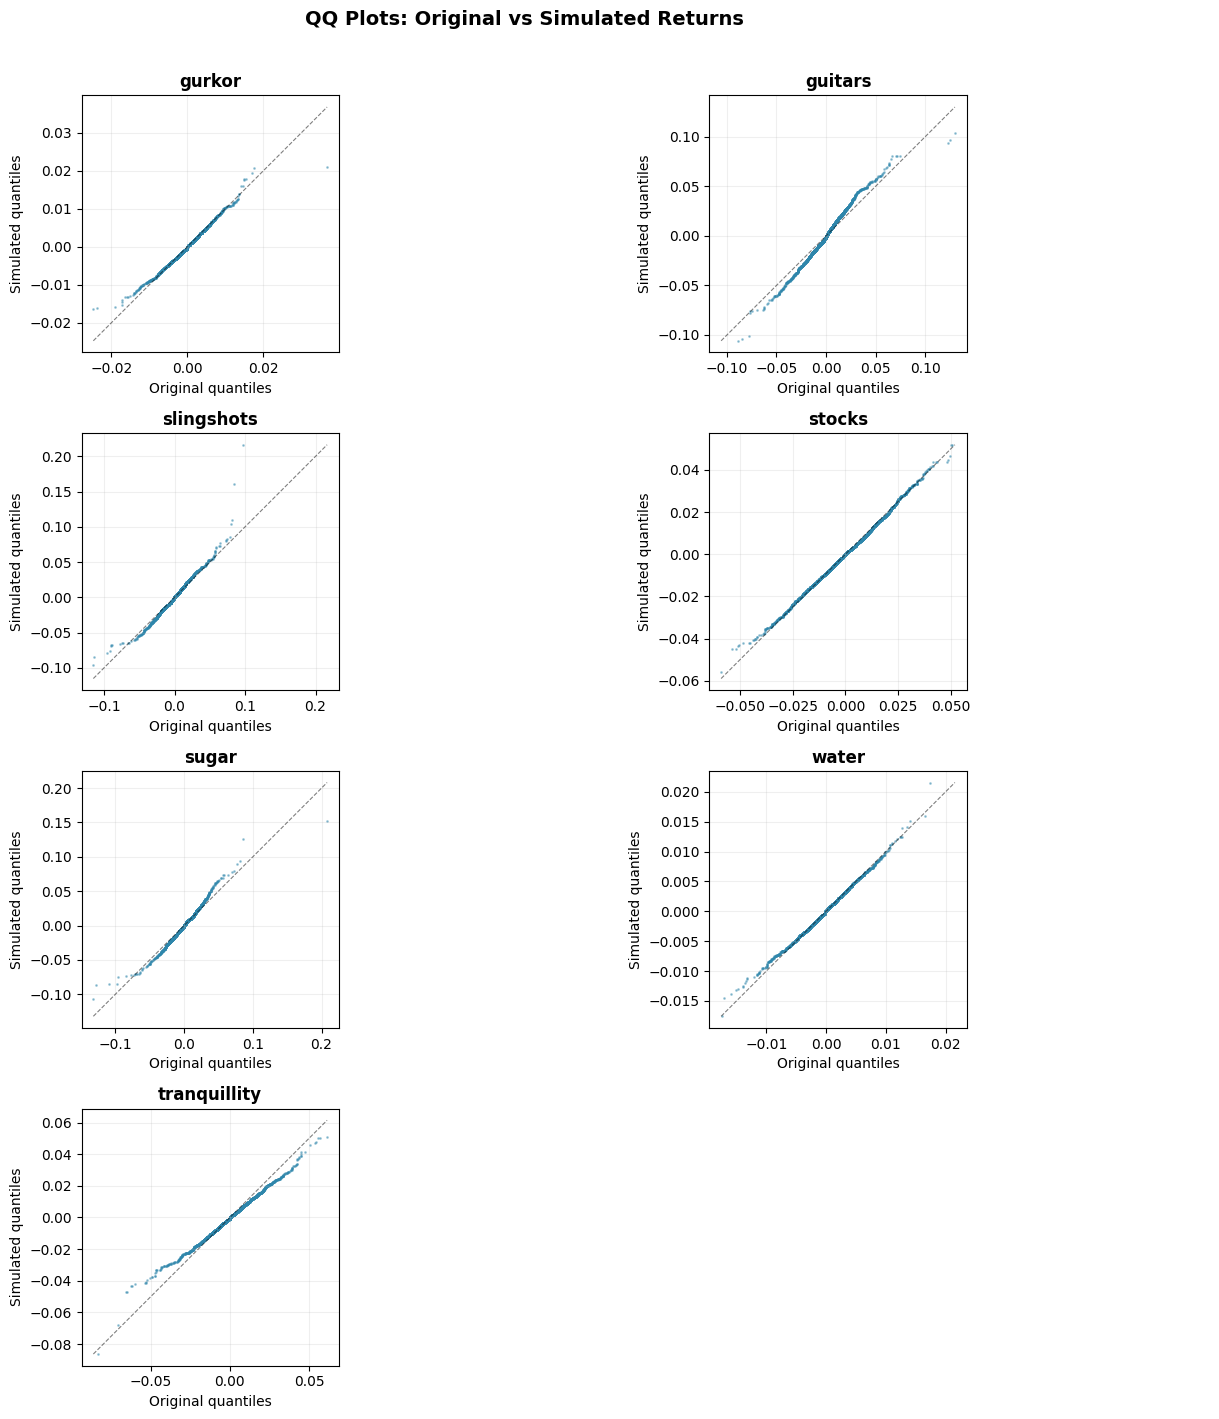

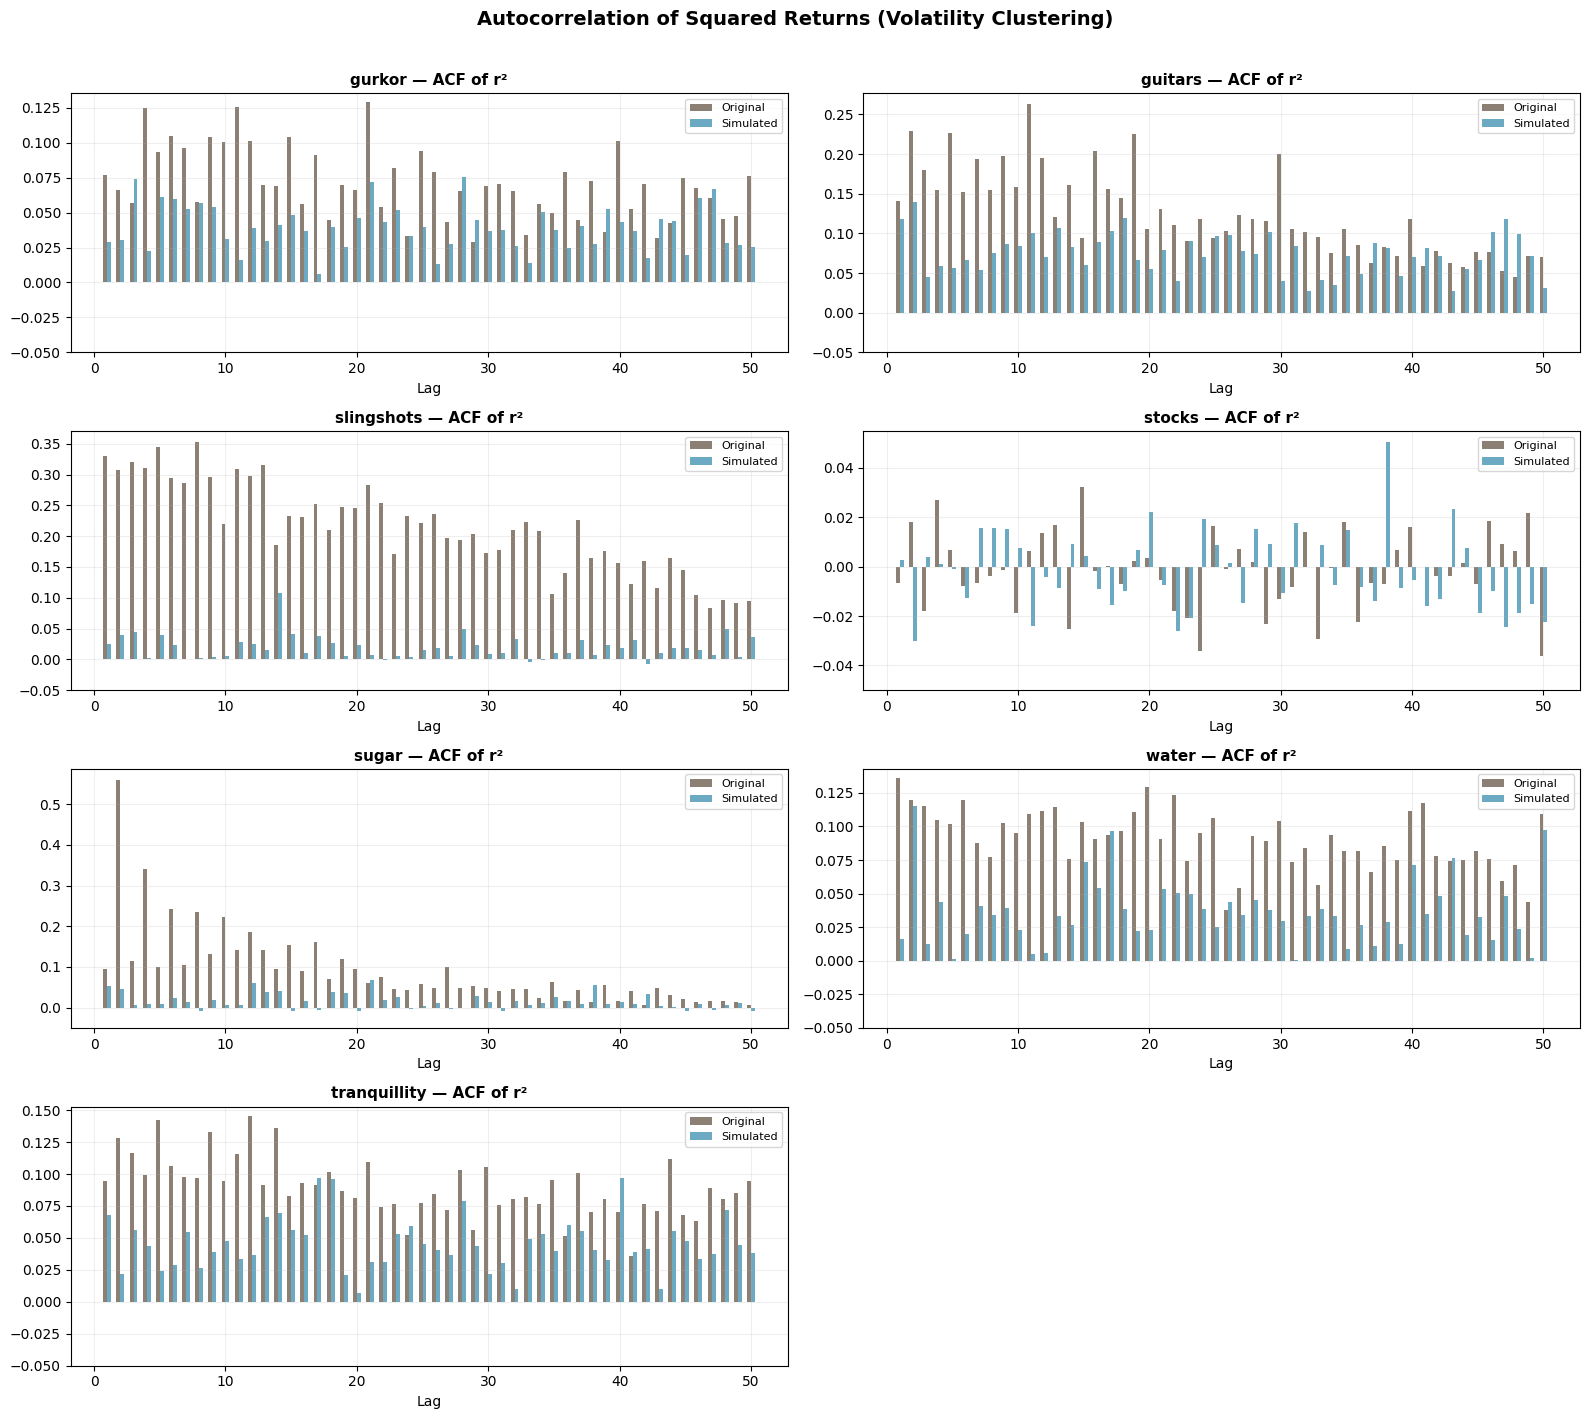

COMPREHENSIVE SUMMARY TABLE
              Mean (og) Mean (sim) Std (og) Std (sim) Skew (og) Skew (sim) Kurt (og) Kurt (sim) KS stat    KS p
Series                                                                                                         
gurkor        -0.000000   0.000033  0.00407   0.00390     -0.06       0.14      3.62       1.63  0.0392  0.0058
guitars       -0.000000   0.000021  0.01602   0.01993      0.21      -0.01      5.75       2.29  0.0716  0.0000
slingshots     0.000000   0.000202  0.01635   0.01846     -0.21       0.66      4.70       8.46  0.0447  0.0010
stocks         0.000000  -0.000033  0.01487   0.01443     -0.09       0.01      0.05       0.09  0.0266  0.1364
sugar         -0.000000  -0.000113  0.01578   0.01783      0.03       0.24     13.47       4.71  0.0550  0.0000
water          0.000000   0.000056  0.00353   0.00343     -0.14       0.05      1.64       1.54  0.0271  0.1225
tranquillity   0.000000  -0.000298  0.01333   0.01105     -0.20      -0.12  

In [4]:
# =============================================================================
# COMPREHENSIVE VALIDATION CELL
# Uses df_returns_final from the main simulation (no re-simulation)
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp, pearsonr
from arch import arch_model

THEME = 'BrBG'

# Use the simulation from cell 1, trimmed to original length
df_sim_real = df_returns_final.iloc[1450:1450+len(df_og_returns)].copy()
df_sim_real.index = df_og_returns.index[:len(df_sim_real)]

# Cumulate to price levels (starting at 100)
df_og_prices = (1 + df_og_returns + original_mean).cumprod() * 100
df_sim_prices = (1 + df_sim_real + original_mean).cumprod() * 100

# =============================================================================
# FIGURE 1: Side-by-side price paths
# =============================================================================
fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=False)
axes = axes.flatten()
for i, col in enumerate(var_names):
    ax = axes[i]
    ax.plot(df_og_prices[col].values, color='#5B4B3A', alpha=0.8, lw=0.7, label='Original')
    ax.plot(df_sim_prices[col].values, color='#2E86AB', alpha=0.8, lw=0.7, label='Simulated')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_ylabel('Price level')
    ax.grid(alpha=0.2)
if len(var_names) < 8:
    axes[-1].axis('off')
fig.suptitle('Price Paths: Original vs Simulated', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('price_paths_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# FIGURE 2: Return distributions (overlaid histograms)
# =============================================================================
fig, axes = plt.subplots(4, 2, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(var_names):
    ax = axes[i]
    ax.hist(df_og_returns[col].values, bins=80, density=True, alpha=0.6,
            color='#5B4B3A', label='Original', edgecolor='none')
    ax.hist(df_sim_real[col].values, bins=80, density=True, alpha=0.5,
            color='#2E86AB', label='Simulated', edgecolor='none')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlim(np.percentile(df_og_returns[col].dropna(), [0.5, 99.5]))
    ax.grid(alpha=0.2)
if len(var_names) < 8:
    axes[-1].axis('off')
fig.suptitle('Return Distributions: Original vs Simulated', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# FIGURE 3: Rolling volatility comparison
# =============================================================================
window = 60
roll_og = df_og_returns.rolling(window).std() * np.sqrt(252)
roll_sim = df_sim_real.rolling(window).std() * np.sqrt(252)

fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(var_names):
    ax = axes[i]
    ax.plot(roll_og[col].values, color='#5B4B3A', alpha=0.8, lw=0.7, label='Original')
    ax.plot(roll_sim[col].values, color='#2E86AB', alpha=0.8, lw=0.7, label='Simulated')
    ax.set_title(f'{col} — {window}-day rolling vol (annualised)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
if len(var_names) < 8:
    axes[-1].axis('off')
fig.suptitle('Rolling Volatility: Original vs Simulated', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('rolling_vol_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# FIGURE 4: Correlation heatmaps (returns + vol) — 2x2
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

sns.heatmap(df_og_returns.corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[0, 0], vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
axes[0, 0].set_title('Return Corr — Original', fontweight='bold')
sns.heatmap(df_sim_real.corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[0, 1], vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
axes[0, 1].set_title('Return Corr — Simulated', fontweight='bold')

cv_og = pd.DataFrame(index=df_og_returns.index, dtype=float)
cv_sim = pd.DataFrame(index=range(len(df_sim_real)), dtype=float)
for col in var_names:
    r1 = arch_model(df_og_returns[col]*1000, vol='Garch', p=1, q=1, mean='Zero').fit(disp='off')
    cv_og[col] = r1.conditional_volatility**2
    r2 = arch_model(df_sim_real[col]*1000, vol='Garch', p=1, q=1, mean='Zero').fit(disp='off')
    cv_sim[col] = r2.conditional_volatility**2

sns.heatmap(np.log(cv_og).corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[1, 0], vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
axes[1, 0].set_title('Cond. Vol Corr — Original', fontweight='bold')
sns.heatmap(np.log(cv_sim).corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[1, 1], vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
axes[1, 1].set_title('Cond. Vol Corr — Simulated', fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_heatmaps_4panel.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# FIGURE 5: QQ plots per series
# =============================================================================
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()
for i, col in enumerate(var_names):
    ax = axes[i]
    og_sorted = np.sort(df_og_returns[col].dropna().values)
    sim_sorted = np.sort(df_sim_real[col].values)
    n = min(len(og_sorted), len(sim_sorted))
    q_og = np.quantile(og_sorted, np.linspace(0, 1, n))
    q_sim = np.quantile(sim_sorted, np.linspace(0, 1, n))
    ax.scatter(q_og, q_sim, s=1, alpha=0.4, color='#2E86AB')
    lims = [min(q_og.min(), q_sim.min()), max(q_og.max(), q_sim.max())]
    ax.plot(lims, lims, 'k--', lw=0.8, alpha=0.5)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Original quantiles')
    ax.set_ylabel('Simulated quantiles')
    ax.grid(alpha=0.2)
    ax.set_aspect('equal')
if len(var_names) < 8:
    axes[-1].axis('off')
fig.suptitle('QQ Plots: Original vs Simulated Returns', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('qq_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# FIGURE 6: ACF of squared returns
# =============================================================================
max_lag = 50
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(var_names):
    ax = axes[i]
    og_sq = (df_og_returns[col]**2).dropna()
    sim_sq = df_sim_real[col]**2

    acf_og = [og_sq.autocorr(lag=l) for l in range(1, max_lag+1)]
    acf_sim = [sim_sq.autocorr(lag=l) for l in range(1, max_lag+1)]

    ax.bar(np.arange(1, max_lag+1) - 0.15, acf_og, width=0.3, alpha=0.7,
           color='#5B4B3A', label='Original')
    ax.bar(np.arange(1, max_lag+1) + 0.15, acf_sim, width=0.3, alpha=0.7,
           color='#2E86AB', label='Simulated')
    ax.set_title(f'{col} — ACF of r²', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel('Lag')
    ax.grid(alpha=0.2)
    ax.set_ylim(bottom=-0.05)
if len(var_names) < 8:
    axes[-1].axis('off')
fig.suptitle('Autocorrelation of Squared Returns (Volatility Clustering)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('acf_squared_returns.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# Summary statistics table
# =============================================================================
print("=" * 80)
print("COMPREHENSIVE SUMMARY TABLE")
print("=" * 80)

summary_rows = []
for col in var_names:
    og = df_og_returns[col].dropna()
    sim = df_sim_real[col]

    ks_stat, ks_p = ks_2samp(og.values, sim.values)

    summary_rows.append({
        'Series': col,
        'Mean (og)': f'{og.mean():.6f}',
        'Mean (sim)': f'{sim.mean():.6f}',
        'Std (og)': f'{og.std():.5f}',
        'Std (sim)': f'{sim.std():.5f}',
        'Skew (og)': f'{og.skew():.2f}',
        'Skew (sim)': f'{sim.skew():.2f}',
        'Kurt (og)': f'{og.kurt():.2f}',
        'Kurt (sim)': f'{sim.kurt():.2f}',
        'KS stat': f'{ks_stat:.4f}',
        'KS p': f'{ks_p:.4f}',
    })

df_summary = pd.DataFrame(summary_rows).set_index('Series')
print(df_summary.to_string())

# Correlation error summary
print("\n" + "=" * 80)
print("CORRELATION ERROR SUMMARY")
print("=" * 80)
mask = ~np.eye(7, dtype=bool)
og_rc = df_og_returns.corr().values
sim_rc = df_sim_real.corr().values
og_vc = np.log(cv_og).corr().values
sim_vc2 = np.log(cv_sim).corr().values

print(f"Return correlation MAE:     {np.mean(np.abs(og_rc[mask] - sim_rc[mask])):.4f}")
print(f"Return correlation max err: {np.max(np.abs(og_rc[mask] - sim_rc[mask])):.4f}")
print(f"Vol correlation MAE:        {np.mean(np.abs(og_vc[mask] - sim_vc2[mask])):.4f}")
print(f"Vol correlation max err:    {np.max(np.abs(og_vc[mask] - sim_vc2[mask])):.4f}")

print("\nLargest vol correlation errors:")
errs = []
for i in range(7):
    for j in range(i+1, 7):
        errs.append((var_names[i], var_names[j], og_vc[i,j], sim_vc2[i,j], og_vc[i,j]-sim_vc2[i,j]))
errs.sort(key=lambda x: abs(x[4]), reverse=True)
for a, b, ov, sv, e in errs[:10]:
    print(f"  {a:>12s} - {b:<12s}: orig={ov:+.2f}  sim={sv:+.2f}  err={e:+.3f}")

In [5]:
import numpy as np
import pandas as pd
from arch import arch_model
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, t as student_t
from scipy.linalg import solve_discrete_lyapunov
from numpy.linalg import eigh

THEME = 'BrBG'

# =============================================================================
# Load data
# =============================================================================
df_og = pd.read_csv('../data/spiff_data-2.csv')
df_og = df_og.replace(1000, np.nan).iloc[1450:]
df_original = df_og.drop(columns=['Unnamed: 0']).set_index('day')

df_og_returns = (df_original / df_original.shift(1) - 1).dropna()
original_mean = df_og_returns.mean()
df_og_returns = df_og_returns - original_mean
original_stds = df_og_returns.std()

var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

# =============================================================================
# VAR(2) parameters (return mean dynamics — unchanged)
# =============================================================================
Phi1 = np.array([
    [ 0.066837, -0.047029, -0.032074, -0.129388, -0.120289, -0.162173,  0.029557],
    [ 0.123793, -0.006606,  0.033206, -0.265276, -0.075745,  0.035917, -0.058590],
    [ 0.026951,  0.015659,  0.000864, -0.045200, -0.024831,  0.035934, -0.043809],
    [ 0.199106,  0.007784,  0.014711, -0.220926, -0.061257, -0.002547,  0.039002],
    [-0.032751, -0.034423,  0.000487,  0.013779, -0.016192, -0.075896, -0.035988],
    [ 0.016032, -0.018288, -0.006550, -0.033598, -0.052375, -0.296606, -0.023336],
    [-0.014400, -0.001650,  0.021113, -0.040414,  0.006551,  0.035195, -0.182736]
])

Phi2 = np.array([
    [ 0.018276, -0.036829,  0.023368, -0.076605,  0.003404, -0.084637, -0.044700],
    [ 0.040158, -0.042788,  0.016656, -0.044778,  0.012176,  0.000934, -0.006445],
    [ 0.010401, -0.001657, -0.015511, -0.017275, -0.028722, -0.011827,  0.032037],
    [ 0.019280, -0.000785, -0.004241, -0.047150,  0.031045,  0.018171, -0.054329],
    [ 0.005180,  0.028481,  0.002092,  0.008334, -0.009077,  0.014023, -0.009718],
    [ 0.011509, -0.018017, -0.012928,  0.000614,  0.004906, -0.070937,  0.004123],
    [-0.004617,  0.034619,  0.008011, -0.010612, -0.000637,  0.029500, -0.061284]
])

# =============================================================================
# Kurtosis / t-distribution parameters
# =============================================================================
nu_obs = {
    'gurkor': 21.72, 'guitars': 18.53, 'slingshots': 32.79,
    'stocks': 401.88, 'sugar': 17.69, 'water': 22.65, 'tranquillity': 16.41
}
nu_target = {
    'gurkor': 5.66, 'guitars': 5.04, 'slingshots': 5.28,
    'stocks': 132.55, 'sugar': 4.45, 'water': 7.65, 'tranquillity': 6.31
}
alpha_blend = {
    'gurkor': 0.85, 'guitars': 0.727, 'slingshots': 1.0,
    'stocks': 0.8, 'sugar': 1.0, 'water': 0.85, 'tranquillity': 0.77,
}
nu_blended = {col: nu_obs[col] + alpha_blend[col] * (nu_target[col] - nu_obs[col]) for col in var_names}
t_scales = {col: 1.0 / np.sqrt(nu_blended[col] / (nu_blended[col] - 2)) for col in var_names}

# =============================================================================
# Iterative calibration: inflate target vol correlations to compensate
# for GARCH attenuation
#
# 1. Simulate with current target
# 2. Re-fit GARCH, measure recovered vol correlations
# 3. Compute ratio: target / recovered  (element-wise)
# 4. Inflate target by that ratio
# 5. Repeat
# =============================================================================

# Original GARCH conditional vol correlations (our TRUE target for validation)
cond_var_og_cal = pd.DataFrame(index=df_og_returns.index, dtype=float)
for col in var_names:
    model = arch_model(df_og_returns[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var_og_cal[col] = res.conditional_volatility ** 2
og_garch_corr = np.log(cond_var_og_cal).corr().values

# Start with the raw log-vol level correlations as initial target
Sigma_target = log_h_std.cov().values
target_corr = Sigma_target / np.sqrt(np.outer(np.diag(Sigma_target), np.diag(Sigma_target)))
target_stds = np.sqrt(np.diag(Sigma_target))

N_CALIB_ITER = 8
T_calib = 15_000
burn_calib = 2000
DAMP = 0.6                # 0.5–0.7 works well
EPS = 1e-4

for iteration in range(N_CALIB_ITER):
    print(f"\n{'='*60}")
    print(f"CALIBRATION ITERATION {iteration + 1}")
    print(f"{'='*60}")

    # Build Sigma_eps from current target correlation + original marginal variances
    current_Sigma = np.outer(target_stds, target_stds) * target_corr
    Sigma_eps_cal = np.zeros((7, 7))
    for i in range(7):
        for j in range(7):
            Sigma_eps_cal[i, j] = current_Sigma[i, j] * (1 - phi_vec[i] * phi_vec[j])

    # Check PD, regularize if needed
    eigs_cal = np.linalg.eigvals(Sigma_eps_cal)
    if np.any(np.real(eigs_cal) <= 0):
        print("  Sigma_eps not PD, regularizing...")
        eigs_real, V = np.linalg.eigh(Sigma_eps_cal)
        eigs_real = np.maximum(eigs_real, 1e-8)
        Sigma_eps_cal = V @ np.diag(eigs_real) @ V.T
        Sigma_eps_cal = (Sigma_eps_cal + Sigma_eps_cal.T) / 2

    L_eps_cal = np.linalg.cholesky(Sigma_eps_cal)

    # Short simulation for calibration
    np.random.seed(42 + iteration)
    T_cal_total = T_calib + burn_calib
    lh_cal = np.zeros((T_cal_total, 7))
    for i in range(7):
        if abs(phi_vec[i]) < 1:
            lh_cal[0, i] = c_vec[i] / (1 - phi_vec[i])
    for t in range(1, T_cal_total):
        eps = L_eps_cal @ np.random.randn(7)
        for i in range(7):
            lh_cal[t, i] = c_vec[i] + phi_vec[i] * lh_cal[t - 1, i] + eps[i]

    lh_cal = lh_cal[burn_calib:]
    log_h_cal = lh_cal * log_h_stds + log_h_means
    h_cal = np.exp(log_h_cal)

    # Generate returns with this vol
    F_cal = np.zeros((T_cal_total, 7))
    for t in range(2, T_cal_total):
        F_cal[t] = Phi1 @ F_cal[t - 1] + Phi2 @ F_cal[t - 2] + np.random.randn(7)
    F_cal = F_cal[burn_calib:]

    Y_cal = F_cal @ Lambda_corrected.T
    Y_cal_std = Y_cal / Y_cal.std(axis=0)

    Y_cal_final = np.zeros_like(Y_cal)
    for t in range(len(Y_cal)):
        u = norm.cdf(Y_cal_std[t])
        ct = np.array([student_t.ppf(u[i], df=nu_blended[col]) * t_scales[col]
                        for i, col in enumerate(var_names)])
        Y_cal_final[t] = ct * np.sqrt(h_cal[t])

    df_cal = pd.DataFrame(Y_cal_final, columns=var_names)
    sf = original_stds / df_cal.std()
    df_cal = df_cal.multiply(sf, axis=1)

    # Re-fit GARCH, get recovered vol correlations
    cv_cal = pd.DataFrame(index=range(len(df_cal)), dtype=float)
    for col in var_names:
        res = arch_model(df_cal[col] * 1000, vol='Garch', p=1, q=1, mean='Zero').fit(disp='off')
        cv_cal[col] = res.conditional_volatility ** 2

    recovered_corr = np.log(cv_cal).corr().values
    mask_od = ~np.eye(7, dtype=bool)

    ratio = og_garch_corr / np.maximum(np.abs(recovered_corr), EPS)
    correction = DAMP * (ratio - 1.0)               # relative error
    target_corr_new = target_corr * (1.0 + correction)
    
    # Safety
    target_corr_new = np.clip(target_corr_new, -0.999, 0.999)
    np.fill_diagonal(target_corr_new, 1.0)
    
    # Project back to valid correlation matrix
    eigs, V = np.linalg.eigh(target_corr_new)
    eigs = np.maximum(eigs, 1e-6)
    target_corr_new = V @ np.diag(eigs) @ V.T
    d = np.sqrt(np.diag(target_corr_new))
    target_corr_new = target_corr_new / np.outer(d, d)
    
    target_corr = target_corr_new
    
    mae_now = np.mean(np.abs(og_garch_corr[mask_od] - recovered_corr[mask_od]))
    print(f"Iter {iteration+1:2d}  vol-corr MAE: {mae_now:.4f}")

    # Compute correction ratio: where recovered is too low, inflate target
    # target_corr_new(i,j) = target_corr(i,j) * og_garch_corr(i,j) / recovered_corr(i,j)
    # Use additive correction for stability (avoids divide-by-near-zero)
    correction = np.zeros((7, 7))
    for i in range(7):
        for j in range(7):
            if i != j:
                error = og_garch_corr[i, j] - recovered_corr[i, j]
                # Additive: add the error, damped to avoid overshoot
                correction[i, j] = 0.8 * error

    target_corr_new = target_corr + correction

    # Clamp to valid correlation range
    target_corr_new = np.clip(target_corr_new, -0.999, 0.999)
    np.fill_diagonal(target_corr_new, 1.0)

    # Ensure PD via eigenvalue clipping
    eigs_tc, V_tc = np.linalg.eigh(target_corr_new)
    if np.any(eigs_tc <= 0):
        eigs_tc = np.maximum(eigs_tc, 1e-4)
        target_corr_new = V_tc @ np.diag(eigs_tc) @ V_tc.T
        d_tc = np.sqrt(np.diag(target_corr_new))
        target_corr_new = target_corr_new / np.outer(d_tc, d_tc)

    target_corr = target_corr_new

    print(f"  Updated target correlations (sample pairs):")
    for (a, b) in [('gurkor','sugar'), ('guitars','stocks'), ('guitars','slingshots')]:
        ia, ib = var_names.index(a), var_names.index(b)
        print(f"    {a}-{b}: og_garch={og_garch_corr[ia,ib]:+.3f}, "
              f"recovered={recovered_corr[ia,ib]:+.3f}, new_target={target_corr[ia,ib]:+.3f}")

print(f"\n{'='*60}")
print("FINAL CALIBRATED TARGET CORRELATIONS")
print(f"{'='*60}")
print(pd.DataFrame(target_corr, index=var_names, columns=var_names).round(3))

# =============================================================================
# Final simulation with calibrated target
# =============================================================================
Sigma_final = np.outer(target_stds, target_stds) * target_corr
Sigma_eps_final = np.zeros((7, 7))
for i in range(7):
    for j in range(7):
        Sigma_eps_final[i, j] = Sigma_final[i, j] * (1 - phi_vec[i] * phi_vec[j])

# PD check
eigs_f = np.linalg.eigvals(Sigma_eps_final)
if np.any(np.real(eigs_f) <= 0):
    print("Regularizing final Sigma_eps...")
    ef, Vf = np.linalg.eigh(Sigma_eps_final)
    ef = np.maximum(ef, 1e-8)
    Sigma_eps_final = Vf @ np.diag(ef) @ Vf.T
    Sigma_eps_final = (Sigma_eps_final + Sigma_eps_final.T) / 2

L_eps = np.linalg.cholesky(Sigma_eps_final)

np.random.seed(69)
T = 20_000
burn = 2000
T_total = T + burn

# VAR(2) return factors
F_sim = np.zeros((T_total, 7))
for t in range(2, T_total):
    F_sim[t] = Phi1 @ F_sim[t - 1] + Phi2 @ F_sim[t - 2] + np.random.randn(7)

# AR(1) log-vol with calibrated correlated innovations
log_h_sim_std = np.zeros((T_total, 7))
for i in range(7):
    if abs(phi_vec[i]) < 1:
        log_h_sim_std[0, i] = c_vec[i] / (1 - phi_vec[i])

for t in range(1, T_total):
    eps = L_eps @ np.random.randn(7)
    for i in range(7):
        log_h_sim_std[t, i] = c_vec[i] + phi_vec[i] * log_h_sim_std[t - 1, i] + eps[i]

log_h_sim = log_h_sim_std * log_h_stds + log_h_means
h_sim = np.exp(log_h_sim)

F_sim = F_sim[burn:]
h_sim = h_sim[burn:]

Y_sim = F_sim @ Lambda_corrected.T
Y_sim_std = Y_sim / Y_sim.std(axis=0)
Z = Y_sim_std

Y_final = np.zeros_like(Y_sim)
for t in range(len(Y_sim)):
    uniform = norm.cdf(Z[t])
    correlated_t = np.array([
        student_t.ppf(uniform[i], df=nu_blended[col]) * t_scales[col]
        for i, col in enumerate(var_names)
    ])
    Y_final[t] = correlated_t * np.sqrt(h_sim[t])

df_returns_final = pd.DataFrame(Y_final, columns=var_names)
scale_factors = original_stds / df_returns_final.std()
df_returns_final = df_returns_final.multiply(scale_factors, axis=1)

# =============================================================================
# VALIDATION
# =============================================================================
print("=" * 60)
print("VALIDATION")
print("=" * 60)

print("\nCorrelation matrix comparison:")
print("Original:")
print(df_og_returns.corr().round(3))
print("\nSimulated:")
print(df_returns_final.corr().round(3))

mask = ~np.eye(7, dtype=bool)
og_c = df_og_returns.corr().values
sim_c = df_returns_final.corr().values
print(f"\nReturn correlation MAE: {np.mean(np.abs(og_c[mask] - sim_c[mask])):.4f}")

print("\nKurtosis comparison:")
print(pd.DataFrame({
    'Original': df_og_returns.kurt(),
    'Simulated': df_returns_final.kurt()
}).round(2))

print("\nGARCH persistence on simulated series:")
for col in var_names:
    res = arch_model(df_returns_final[col] * 1000, vol='Garch', p=1, q=1, mean='Zero').fit(disp='off')
    p_sim = res.params['alpha[1]'] + res.params['beta[1]']
    print(f"  {col}: {p_sim:.4f}")

print("\n" + "=" * 60)
print("CONDITIONAL VOLATILITY CORRELATIONS")
print("=" * 60)

cond_var_sim = pd.DataFrame(index=range(len(df_returns_final)), dtype=float)
for col in var_names:
    res = arch_model(df_returns_final[col] * 1000, vol='Garch', p=1, q=1, mean='Zero').fit(disp='off')
    cond_var_sim[col] = res.conditional_volatility ** 2

cond_var_og2 = pd.DataFrame(index=df_og_returns.index, dtype=float)
for col in var_names:
    res = arch_model(df_og_returns[col] * 1000, vol='Garch', p=1, q=1, mean='Zero').fit(disp='off')
    cond_var_og2[col] = res.conditional_volatility ** 2

print("\nOriginal conditional vol correlations:")
print(np.log(cond_var_og2).corr().round(2))
print("\nSimulated conditional vol correlations:")
print(np.log(cond_var_sim).corr().round(2))

og_vc = np.log(cond_var_og2).corr().values
sim_vc = np.log(cond_var_sim).corr().values
mae_vol = np.mean(np.abs(og_vc[mask] - sim_vc[mask]))
print(f"\nVol correlation MAE: {mae_vol:.3f}")

print("\nLargest vol correlation errors:")
errs = []
for i in range(7):
    for j in range(i + 1, 7):
        errs.append((var_names[i], var_names[j], og_vc[i, j], sim_vc[i, j],
                      og_vc[i, j] - sim_vc[i, j]))
errs.sort(key=lambda x: abs(x[4]), reverse=True)
for a, b, ov, sv, e in errs[:10]:
    print(f"  {a:>12s} - {b:<12s}: orig={ov:+.2f}  sim={sv:+.2f}  err={e:+.3f}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(np.log(cond_var_og2).corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Conditional Vol Correlation — Original')
sns.heatmap(np.log(cond_var_sim).corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Conditional Vol Correlation — Simulated')
plt.tight_layout()
plt.savefig('vol_corr_comparison.png', dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(df_og_returns.corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Return Correlation — Original')
sns.heatmap(df_returns_final.corr(), annot=True, fmt='.2f', cmap=THEME,
            center=0, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Return Correlation — Simulated')
plt.tight_layout()
plt.savefig('return_corr_comparison.png', dpi=150)
plt.show()


CALIBRATION ITERATION 1


NameError: name 'phi_vec' is not defined

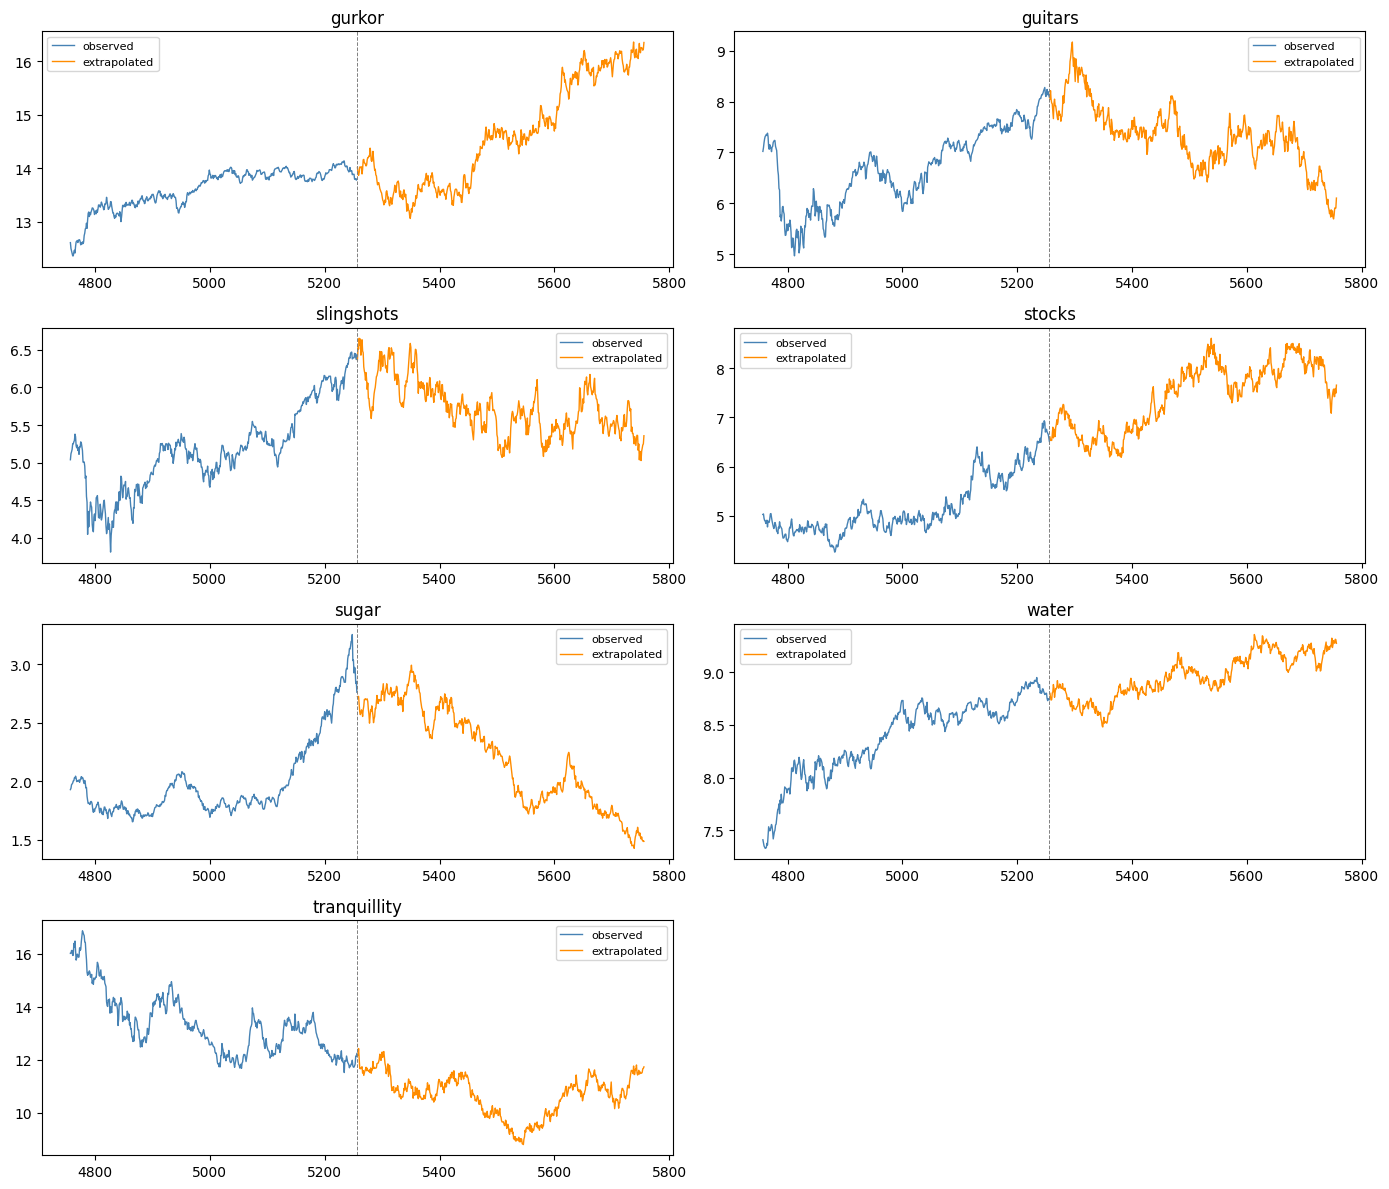

,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
5257,14.011623,8.051267,6.368419,6.603593,2.721896,8.799382,12.155225
5258,13.897826,8.213315,6.528722,6.534605,2.724722,8.760502,12.183731
5259,13.863642,8.039568,6.507049,6.538705,2.723987,8.735220,12.418167
5260,13.916186,7.972591,6.652209,6.531543,2.663356,8.738933,12.000256
5261,14.020775,7.952221,6.559133,6.645913,2.591239,8.801607,11.662775


In [ ]:
# =============================================================================
# Simple extrapolation: forecast 300 days beyond the original dataset
# Re-uses Phi1, Phi2 and a Gaussian innovation covariance fit on the VAR(2)
# residuals — drops the GARCH/PCA/t-copula machinery.
# =============================================================================
np.random.seed(7)
H = 200  # days to extrapolate

# Use the last valid (non-NaN) rows of df_original — trailing rows are all-NaN
df_clean = df_original.dropna()
last_price = df_clean.iloc[-1].values
last_day = int(df_clean.index[-1])

# Centered simple returns — same convention as the sim above
Y_obs = df_og_returns.values  # already centered by `original_mean`

# Innovation covariance from VAR(2) residuals on the observed data
resid = Y_obs[2:] - Y_obs[1:-1] @ Phi1.T - Y_obs[:-2] @ Phi2.T
Sigma_eps = np.cov(resid, rowvar=False)
L_eps = np.linalg.cholesky(Sigma_eps + 1e-12 * np.eye(7))

# Seed with the last two observed return vectors, then iterate VAR(2)
Y_extrap = np.zeros((H + 2, 7))
Y_extrap[0] = Y_obs[-2]
Y_extrap[1] = Y_obs[-1]
for t in range(2, H + 2):
    eps = L_eps @ np.random.randn(7)
    Y_extrap[t] = Phi1 @ Y_extrap[t - 1] + Phi2 @ Y_extrap[t - 2] + eps

# Add back the mean, cumulate from the last observed price
returns_extrap = Y_extrap[2:] + original_mean.values
prices_extrap = last_price * np.cumprod(1.0 + returns_extrap, axis=0)
future_days = np.arange(last_day + 1, last_day + 1 + H)
df_extrap = pd.DataFrame(prices_extrap, index=future_days, columns=var_names)
df_extrap.index.name = 'day'

# Plot: observed tail + extrapolation
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
tail = 500
for ax, col in zip(axes.flat, var_names):
    ax.plot(df_clean.index[-tail:], df_clean[col].iloc[-tail:],
            color='steelblue', lw=1, label='observed')
    ax.plot(df_extrap.index, df_extrap[col],
            color='darkorange', lw=1, label='extrapolated')
    ax.axvline(last_day, color='grey', lw=0.7, ls='--')
    ax.set_title(col)
    ax.legend(loc='best', fontsize=8)
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

df_extrap.head()
